<a href="https://colab.research.google.com/github/SudheerKothapalli/PulmoScan.AI/blob/main/PulmoScanAI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q kagglehub \
               segmentation-models-pytorch \
               efficientnet_pytorch \
               grad-cam \
               flask \
               flask-cors \
               pyngrok \
               opencv-python-headless \
               scikit-learn \
               Pillow \
               numpy \
               seaborn \
               matplotlib

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 80.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 16.0 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
from google.colab import files

print("Upload your kaggle.json file...")
uploaded = files.upload()

import os
os.makedirs(os.path.expanduser("~/.kaggle"), exist_ok=True)
os.rename("kaggle.json", os.path.expanduser("~/.kaggle/kaggle.json"))
os.chmod(os.path.expanduser("~/.kaggle/kaggle.json"), 0o600)
print("Kaggle credentials configured successfully!")

Upload your kaggle.json file...


Saving kaggle.json to kaggle.json
Kaggle credentials configured successfully!


In [ ]:
import os
import io
import base64
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2

import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.models as models

import segmentation_models_pytorch as smp

from flask import Flask, request, jsonify
from flask_cors import CORS
from PIL import Image
from torchvision import datasets
from torch.utils.data import Dataset, DataLoader
from efficientnet_pytorch import EfficientNet

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    auc,
    precision_score,
    recall_score,
    f1_score
)
from sklearn.preprocessing import label_binarize
from pyngrok import ngrok

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device     : {device}")
print(f"GPU Active : {torch.cuda.is_available()}")

Device     : cuda
GPU Active : True


In [ ]:
import kagglehub

# Download segmentation dataset
print("Downloading segmentation dataset...")
seg_path  = kagglehub.dataset_download("kmader/finding-lungs-in-ct-data")
image_dir = os.path.join(seg_path, "2d_images")
mask_dir  = os.path.join(seg_path, "2d_masks")
print(f"  Segmentation images found : {len(os.listdir(image_dir))}")

# Download classification dataset
print("Downloading classification dataset...")
clf_path = kagglehub.dataset_download("mohamedhanyyy/chest-ctscan-images")
print(f"  Classification path : {clf_path}")

print("Both datasets downloaded successfully!")

Using Colab cache for faster access to the 'finding-lungs-in-ct-data' dataset.
  Segmentation images found : 267


100%|██████████| 119M/119M [00:00<00:00, 138MB/s]

Extracting files...


  Classification path : /root/.cache/kagglehub/datasets/mohamedhanyyy/chest-ctscan-images/versions/1
Both datasets downloaded successfully!


In [ ]:
seg_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

clf_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor()
])

val_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

infer_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

train_ds = datasets.ImageFolder(
    os.path.join(clf_path, "Data/train"), clf_tf
)
val_ds = datasets.ImageFolder(
    os.path.join(clf_path, "Data/valid"), val_tf
)
test_ds = datasets.ImageFolder(
    os.path.join(clf_path, "Data/test"), val_tf
)

CLASS_NAMES = train_ds.classes
print(f"Classes  : {CLASS_NAMES}")
print(f"Train    : {len(train_ds)} images")
print(f"Val      : {len(val_ds)} images")
print(f"Test     : {len(test_ds)} images")

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=16)
test_loader  = DataLoader(test_ds,  batch_size=16)


Classes  : ['adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib', 'large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa', 'normal', 'squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa']
Train    : 613 images
Val      : 72 images
Test     : 315 images


In [ ]:
class LungDataset(Dataset):
    def __init__(self, image_dir, mask_dir, transform):
        self.image_dir = image_dir
        self.mask_dir  = mask_dir
        self.images    = sorted(os.listdir(image_dir))
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = Image.open(
            os.path.join(self.image_dir, self.images[idx])
        ).convert("RGB")

        mask = Image.open(
            os.path.join(self.mask_dir, self.images[idx])
        ).convert("L")

        img  = self.transform(img)
        mask = self.transform(mask)

        return img, (mask > 0).float()

# Build segmentation dataset and loader
seg_dataset = LungDataset(image_dir, mask_dir, seg_tf)
seg_loader  = DataLoader(seg_dataset, batch_size=16, shuffle=True)

print(f"Segmentation dataset size : {len(seg_dataset)} images")

Segmentation dataset size : 267 images


In [ ]:
def get_model(name):
    """Build and return model with pretrained ImageNet weights."""

    if name == "resnet50":
        m = models.resnet50(
            weights=models.ResNet50_Weights.IMAGENET1K_V1
        )
        m.fc = nn.Linear(m.fc.in_features, 4)

    elif name == "resnet101":
        m = models.resnet101(
            weights=models.ResNet101_Weights.IMAGENET1K_V1
        )
        m.fc = nn.Linear(m.fc.in_features, 4)

    elif name == "googlenet":
        m = models.googlenet(
            weights=models.GoogLeNet_Weights.IMAGENET1K_V1
        )
        m.fc = nn.Linear(m.fc.in_features, 4)

    elif name == "efficientnet":
        m = EfficientNet.from_pretrained("efficientnet-b0")
        m._fc = nn.Linear(m._fc.in_features, 4)

    return m.to(device)

# Test all 4 models build correctly
MODEL_NAMES = ["resnet50", "resnet101", "googlenet", "efficientnet"]

print("Testing all 4 models...")
for name in MODEL_NAMES:
    m = get_model(name)
    print(f"  {name} built successfully")
del m
print("All 4 models ready!")

Testing all 4 models...
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 122MB/s]


  resnet50 built successfully
Downloading: "https://download.pytorch.org/models/resnet101-63fe2227.pth" to /root/.cache/torch/hub/checkpoints/resnet101-63fe2227.pth


100%|██████████| 171M/171M [00:00<00:00, 181MB/s]


  resnet101 built successfully
Downloading: "https://download.pytorch.org/models/googlenet-1378be20.pth" to /root/.cache/torch/hub/checkpoints/googlenet-1378be20.pth


100%|██████████| 49.7M/49.7M [00:00<00:00, 163MB/s]


  googlenet built successfully
Downloading: "https://github.com/lukemelas/EfficientNet-PyTorch/releases/download/1.0/efficientnet-b0-355c32eb.pth" to /root/.cache/torch/hub/checkpoints/efficientnet-b0-355c32eb.pth


100%|██████████| 20.4M/20.4M [00:00<00:00, 234MB/s]

Loaded pretrained weights for efficientnet-b0
  efficientnet built successfully
All 4 models ready!


In [ ]:
import torch.optim as optim

# Build U-Net with ResNet34 encoder
unet = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1
).to(device)

seg_optimizer = optim.Adam(unet.parameters(), lr=1e-4)
seg_criterion = nn.BCEWithLogitsLoss()

seg_loss_history = []

print("Training U-Net Segmentation Model — 20 epochs")
print("=" * 50)

for epoch in range(20):
    unet.train()
    total_loss = 0

    for imgs, masks in seg_loader:
        imgs, masks = imgs.to(device), masks.to(device)
        outputs     = unet(imgs)
        loss        = seg_criterion(outputs, masks)
        seg_optimizer.zero_grad()
        loss.backward()
        seg_optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(seg_loader)
    seg_loss_history.append(avg_loss)
    print(f"  Epoch {epoch+1:02d}/20 | Loss : {avg_loss:.4f}")

# Save U-Net weights
torch.save(unet.state_dict(), "unet_lung.pth")
print("U-Net training complete! Saved as unet_lung.pth")

# Plot training loss
plt.figure(figsize=(8, 4))
plt.plot(seg_loss_history, color='#00d4aa', linewidth=2)
plt.title("U-Net Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

NameError: name 'smp' is not defined


  Training : RESNET50
  Epoch 01/15 | Train : 70.6% | Val : 72.2%  -- Best saved!
  Epoch 02/15 | Train : 88.3% | Val : 73.6%  -- Best saved!
  Epoch 03/15 | Train : 94.5% | Val : 87.5%  -- Best saved!
  Epoch 04/15 | Train : 94.5% | Val : 84.7%
  Epoch 05/15 | Train : 96.2% | Val : 88.9%  -- Best saved!
  Epoch 06/15 | Train : 96.2% | Val : 88.9%
  Epoch 07/15 | Train : 97.4% | Val : 90.3%  -- Best saved!
  Epoch 08/15 | Train : 96.7% | Val : 84.7%
  Epoch 09/15 | Train : 96.4% | Val : 87.5%
  Epoch 10/15 | Train : 97.6% | Val : 84.7%
  Epoch 11/15 | Train : 97.4% | Val : 90.3%
  Epoch 12/15 | Train : 97.9% | Val : 86.1%
  Epoch 13/15 | Train : 99.5% | Val : 87.5%
  Epoch 14/15 | Train : 98.9% | Val : 90.3%
  Epoch 15/15 | Train : 96.6% | Val : 84.7%

  Training : RESNET101
  Epoch 01/15 | Train : 73.9% | Val : 72.2%  -- Best saved!
  Epoch 02/15 | Train : 88.7% | Val : 73.6%  -- Best saved!
  Epoch 03/15 | Train : 94.0% | Val : 81.9%  -- Best saved!
  Epoch 04/15 | Train : 94.9% | V

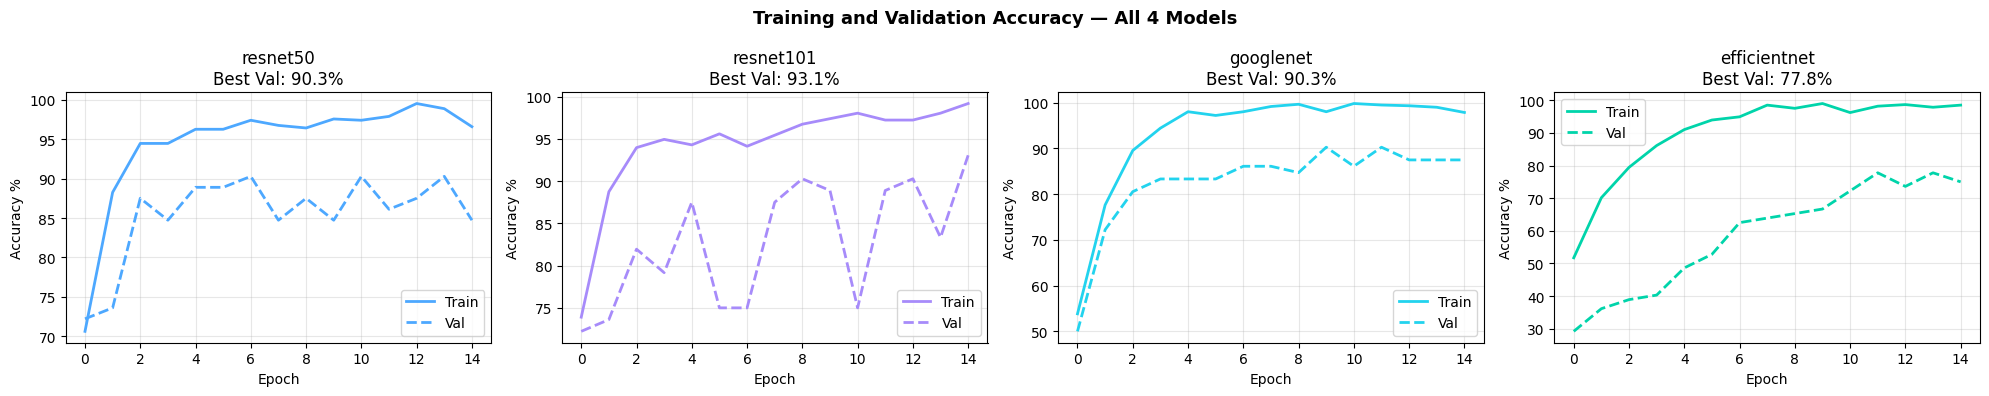

In [ ]:
def train_model(model, model_name, epochs=15):
    """Train a single classification model and save best weights."""

    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
    criterion = nn.CrossEntropyLoss()
    best_val  = 0
    t_hist    = []
    v_hist    = []

    print(f"\n{'=' * 52}")
    print(f"  Training : {model_name.upper()}")
    print(f"{'=' * 52}")

    for epoch in range(epochs):

        # --- Training phase ---
        model.train()
        correct = 0
        total   = 0

        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs      = model(imgs)
            loss         = criterion(outputs, labels)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            _, preds  = torch.max(outputs, 1)
            correct  += (preds == labels).sum().item()
            total    += labels.size(0)

        train_acc = 100 * correct / total
        t_hist.append(train_acc)

        # --- Validation phase ---
        model.eval()
        vc = 0
        vt = 0

        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                outputs      = model(imgs)
                _, preds     = torch.max(outputs, 1)
                vc          += (preds == labels).sum().item()
                vt          += labels.size(0)

        val_acc = 100 * vc / vt
        v_hist.append(val_acc)

        # Save best model
        if val_acc > best_val:
            best_val = val_acc
            torch.save(model.state_dict(), f"{model_name}_clf.pth")
            print(f"  Epoch {epoch+1:02d}/{epochs} | "
                  f"Train : {train_acc:.1f}% | "
                  f"Val : {val_acc:.1f}%  -- Best saved!")
        else:
            print(f"  Epoch {epoch+1:02d}/{epochs} | "
                  f"Train : {train_acc:.1f}% | "
                  f"Val : {val_acc:.1f}%")

    return best_val, t_hist, v_hist


# Train all 4 models one by one
trained_models = {}
val_results    = {}
histories      = {}

for name in MODEL_NAMES:
    model               = get_model(name)
    best, t_h, v_h      = train_model(model, name)
    trained_models[name] = model
    val_results[name]    = best
    histories[name]      = (t_h, v_h)

# Load best weights into the trained_models dictionary for inference
print("\nLoading best weights into trained models...")
for name in MODEL_NAMES:
    if os.path.exists(f"{name}_clf.pth"):
        trained_models[name].load_state_dict(
            torch.load(f"{name}_clf.pth", map_location=device)
        )
        trained_models[name].eval() # Set to evaluation mode
        print(f"  Loaded best weights for {name}.")
    else:
        print(f"  Warning: Best weights for {name} not found. Using last epoch's weights.")

# Print final summary
print("\n" + "=" * 52)
print("  TRAINING COMPLETE — ALL 4 MODELS")
print("=" * 52)
for name, acc in val_results.items():
    crown = "  <-- BEST" if acc == max(val_results.values()) else ""
    print(f"  {name:<18} :  {acc:.2f}%{crown}")
print("=" * 52)
print(f"Class order : {CLASS_NAMES}")

# Plot accuracy curves for all 4 models
fig, axes  = plt.subplots(1, 4, figsize=(20, 4))
bar_colors = ['#4da8ff', '#a78bfa', '#22d3ee', '#00d4aa']

for ax, name, col in zip(axes, MODEL_NAMES, bar_colors):
    t_h, v_h = histories[name]
    ax.plot(t_h, label='Train', color=col,  linewidth=2)
    ax.plot(v_h, label='Val',   color=col,  linewidth=2, linestyle='--')
    ax.set_title(f"{name}\nBest Val: {val_results[name]:.1f}%")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Accuracy %")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle("Training and Validation Accuracy — All 4 Models",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("training_curves.png", dpi=120, bbox_inches='tight')
plt.show()

In [ ]:
def evaluate_model(model, model_name):
    """Evaluate model on test set and return all metrics."""

    # Load best saved weights
    model.load_state_dict(
        torch.load(f"{model_name}_clf.pth", map_location=device)
    )
    model.eval()

    all_preds  = []
    all_labels = []
    all_probs  = []

    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs      = model(imgs)
            probs        = torch.softmax(outputs, dim=1)
            _, preds     = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    all_preds  = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs  = np.array(all_probs)
    accuracy   = 100 * (all_preds == all_labels).mean()

    return accuracy, all_labels, all_preds, all_probs


# Evaluate all 4 models
eval_results = {}

print("Evaluating all 4 models on test set...")
print("=" * 50)

for name in MODEL_NAMES:
    model = trained_models[name]
    acc, labels, preds, probs = evaluate_model(model, name)
    eval_results[name] = {
        "acc"    : acc,
        "labels" : labels,
        "preds"  : preds,
        "probs"  : probs
    }
    crown = "  <-- BEST" if acc == max(
        eval_results[n]["acc"] for n in eval_results
    ) else ""
    print(f"  {name:<18} :  Test Accuracy : {acc:.2f}%{crown}")

best_model_name = max(eval_results, key=lambda n: eval_results[n]["acc"])
print("=" * 50)
print(f"Best model : {best_model_name}  "
      f"({eval_results[best_model_name]['acc']:.2f}%)")

Evaluating all 4 models on test set...
  resnet50           :  Test Accuracy : 88.57%  <-- BEST
  resnet101          :  Test Accuracy : 94.29%  <-- BEST
  googlenet          :  Test Accuracy : 92.38%
  efficientnet       :  Test Accuracy : 82.22%
Best model : resnet101  (94.29%)


Plotting Confusion Matrices and Per-Class Accuracy...


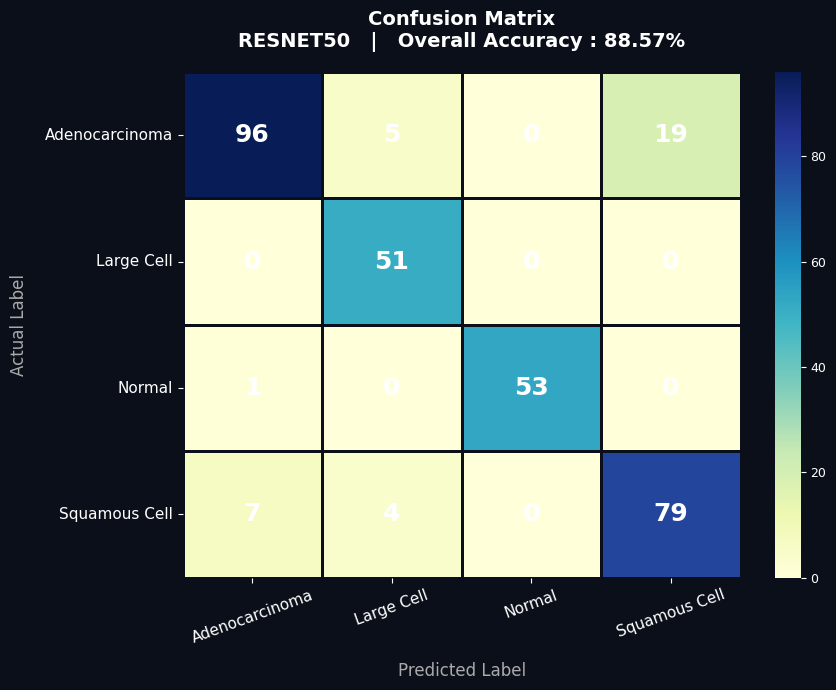

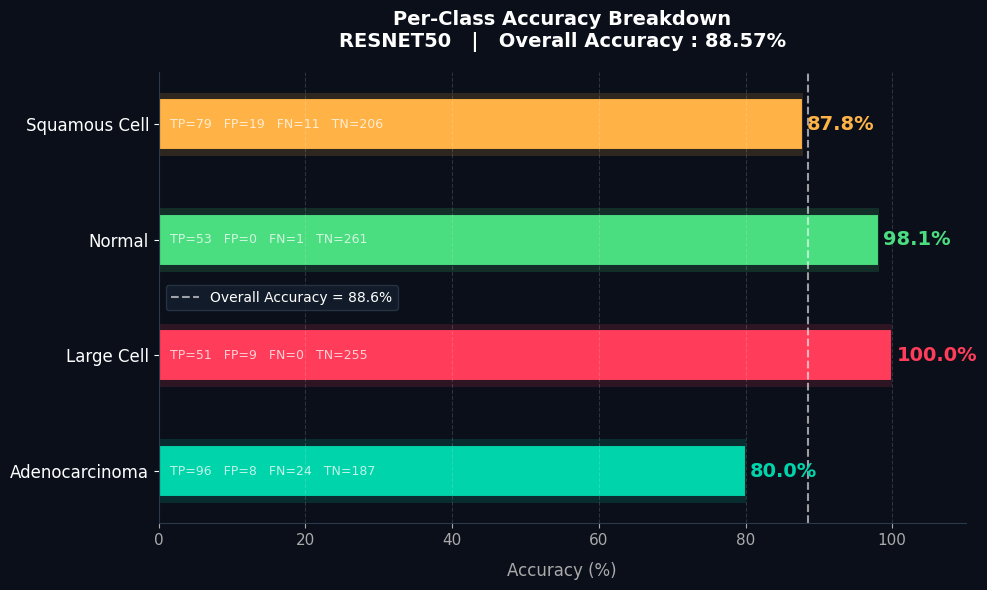


  RESNET50
  Class                     Acc    TP    FP    FN    TN
  ──────────────────────────────────────────────────
  Adenocarcinoma          80.0%    96     8    24   187
  Large Cell             100.0%    51     9     0   255
  Normal                  98.1%    53     0     1   261
  Squamous Cell           87.8%    79    19    11   206
  ──────────────────────────────────────────────────
  Overall Accuracy        88.6%



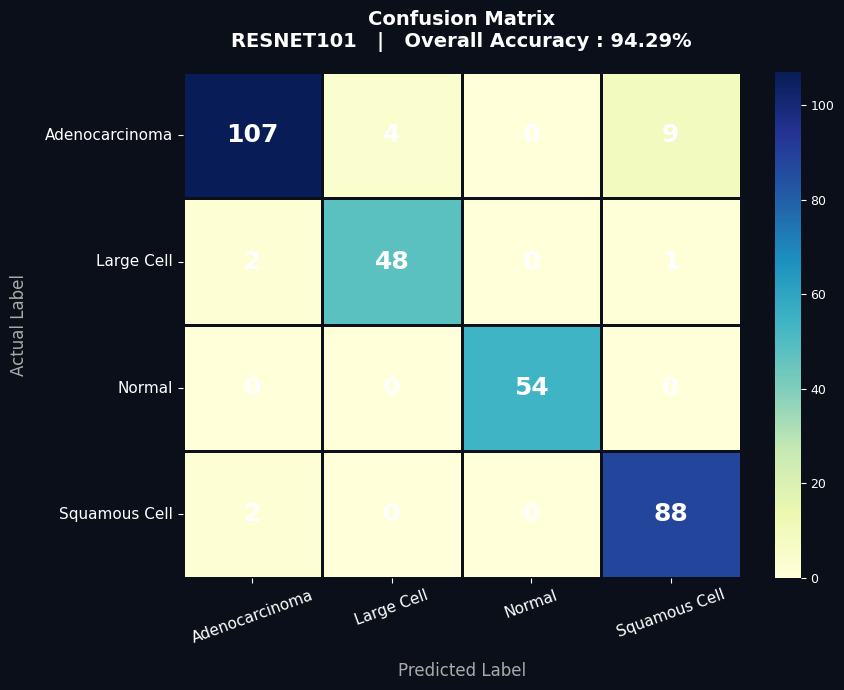

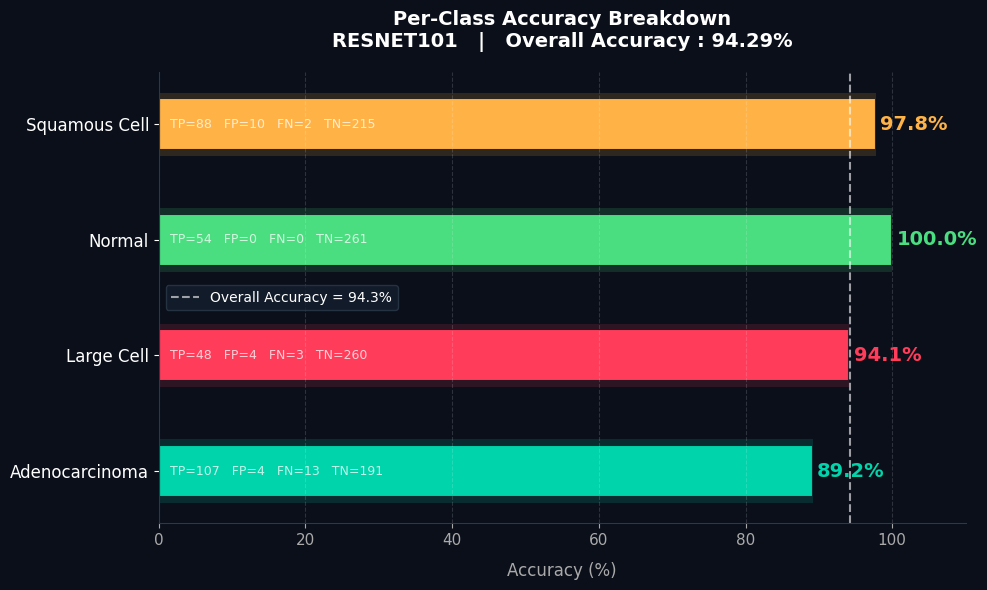


  RESNET101
  Class                     Acc    TP    FP    FN    TN
  ──────────────────────────────────────────────────
  Adenocarcinoma          89.2%   107     4    13   191
  Large Cell              94.1%    48     4     3   260
  Normal                 100.0%    54     0     0   261
  Squamous Cell           97.8%    88    10     2   215
  ──────────────────────────────────────────────────
  Overall Accuracy        94.3%



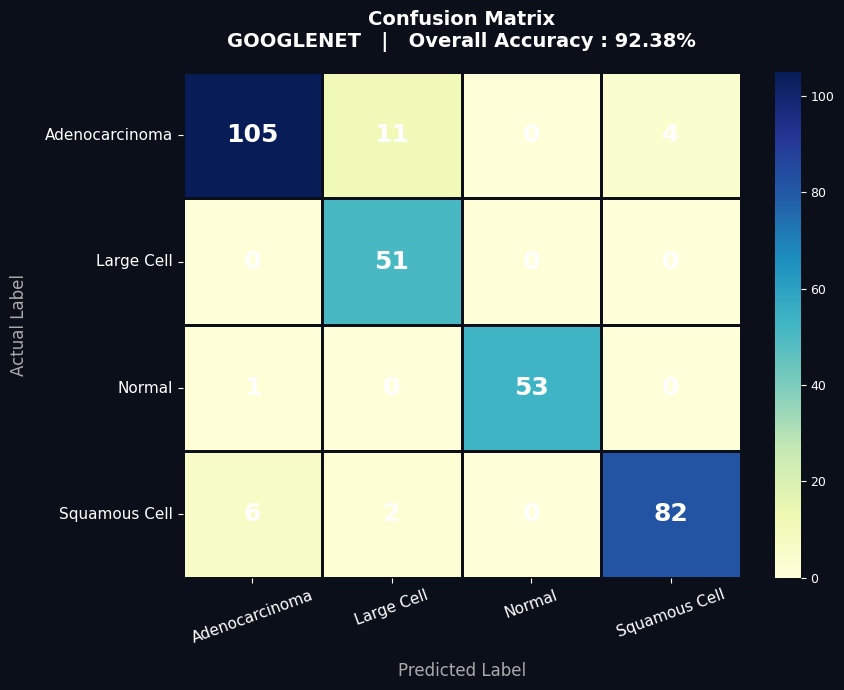

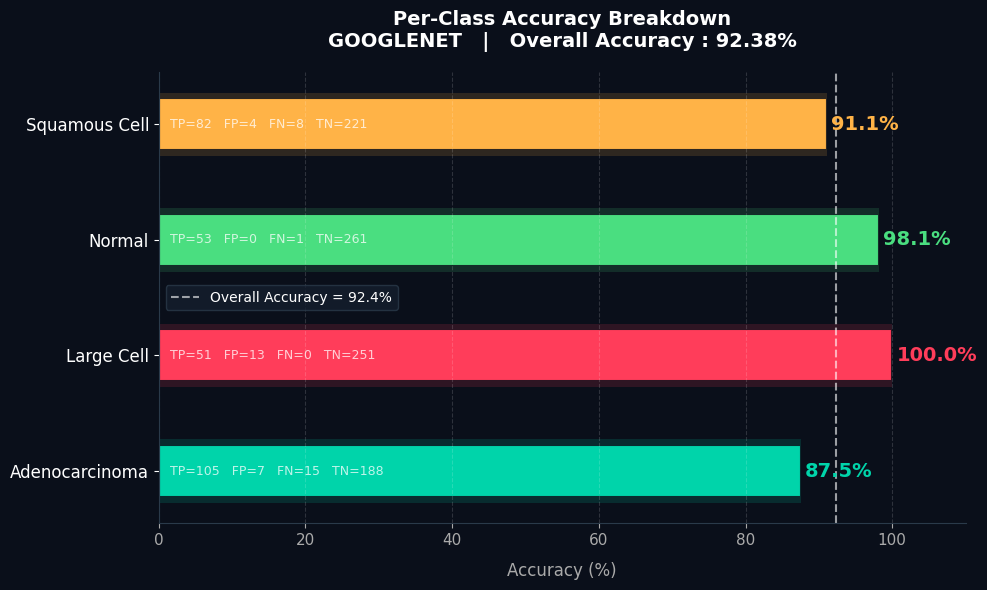


  GOOGLENET
  Class                     Acc    TP    FP    FN    TN
  ──────────────────────────────────────────────────
  Adenocarcinoma          87.5%   105     7    15   188
  Large Cell             100.0%    51    13     0   251
  Normal                  98.1%    53     0     1   261
  Squamous Cell           91.1%    82     4     8   221
  ──────────────────────────────────────────────────
  Overall Accuracy        92.4%



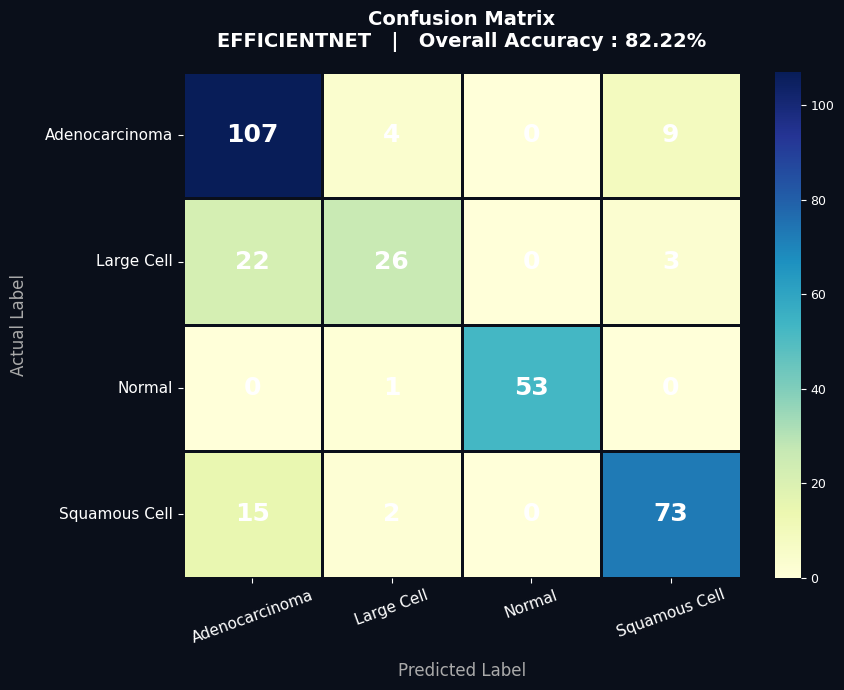

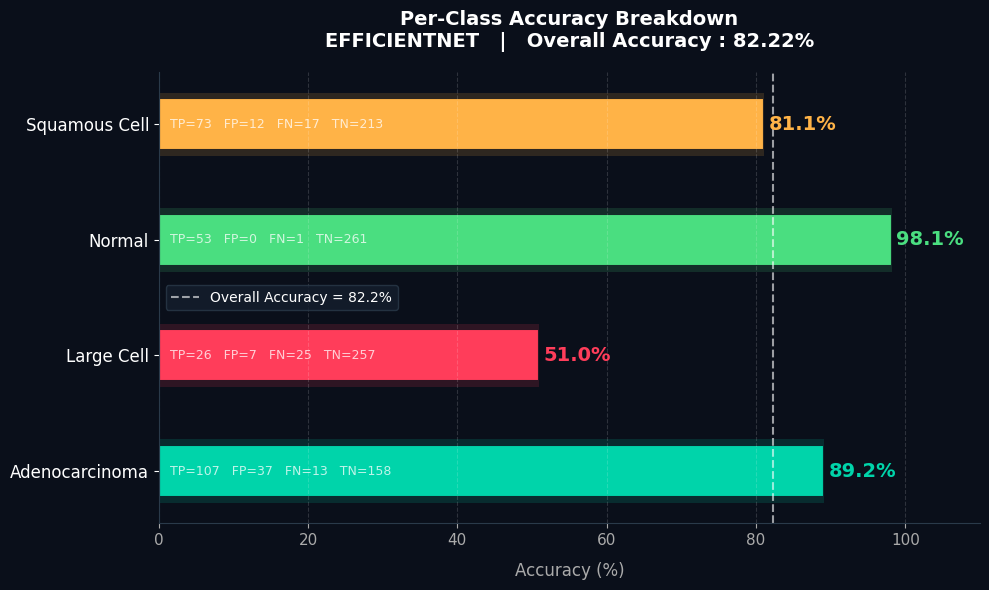


  EFFICIENTNET
  Class                     Acc    TP    FP    FN    TN
  ──────────────────────────────────────────────────
  Adenocarcinoma          89.2%   107    37    13   158
  Large Cell              51.0%    26     7    25   257
  Normal                  98.1%    53     0     1   261
  Squamous Cell           81.1%    73    12    17   213
  ──────────────────────────────────────────────────
  Overall Accuracy        82.2%

All plots saved!

Confusion Matrix files :
  CM_resnet50.png
  CM_resnet101.png
  CM_googlenet.png
  CM_efficientnet.png

Per-Class Accuracy files :
  PerClass_resnet50.png
  PerClass_resnet101.png
  PerClass_googlenet.png
  PerClass_efficientnet.png


In [ ]:
# Clean short class names for display
SHORT_NAMES = [
    "Adenocarcinoma",
    "Large Cell",
    "Normal",
    "Squamous Cell"
]

CLS_COLORS = ['#00d4aa', '#ff3d5a', '#4ade80', '#ffb347']

print("Plotting Confusion Matrices and Per-Class Accuracy...")
print("=" * 55)

for name in MODEL_NAMES:

    r  = eval_results[name]
    cm = confusion_matrix(r["labels"], r["preds"])
    per_class_acc = cm.diagonal() / cm.sum(axis=1) * 100

    # ════════════════════════════════════════════
    # FIGURE 1 — Confusion Matrix only
    # ════════════════════════════════════════════
    fig1, ax1 = plt.subplots(figsize=(9, 7))

    fig1.patch.set_facecolor('#0a0f1a')
    ax1.set_facecolor('#0a0f1a')

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='YlGnBu',
        xticklabels=SHORT_NAMES,
        yticklabels=SHORT_NAMES,
        ax=ax1,
        cbar=True,
        linewidths=2,
        linecolor='#0a0f1a',
        annot_kws={
            "size"   : 18,
            "weight" : "bold",
            "color"  : "white"
        }
    )

    ax1.set_title(
        f"Confusion Matrix\n"
        f"{name.upper()}   |   Overall Accuracy : {r['acc']:.2f}%",
        fontsize=14,
        fontweight='bold',
        color='white',
        pad=18
    )
    ax1.set_xlabel(
        "Predicted Label",
        fontsize=12,
        labelpad=12,
        color='#aaaaaa'
    )
    ax1.set_ylabel(
        "Actual Label",
        fontsize=12,
        labelpad=12,
        color='#aaaaaa'
    )
    ax1.tick_params(
        axis='x',
        rotation=20,
        labelsize=11,
        colors='white'
    )
    ax1.tick_params(
        axis='y',
        rotation=0,
        labelsize=11,
        colors='white'
    )

    # Color bar styling
    cbar = ax1.collections[0].colorbar
    cbar.ax.tick_params(colors='white', labelsize=9)
    cbar.ax.yaxis.label.set_color('white')

    plt.tight_layout()
    plt.savefig(
        f"CM_{name}.png",
        dpi=150,
        bbox_inches='tight',
        facecolor='#0a0f1a'
    )
    plt.show()
    plt.close()

    # ════════════════════════════════════════════
    # FIGURE 2 — Per-Class Accuracy Breakdown only
    # ════════════════════════════════════════════
    fig2, ax2 = plt.subplots(figsize=(10, 6))

    fig2.patch.set_facecolor('#0a0f1a')
    ax2.set_facecolor('#0a0f1a')

    # Horizontal bars
    bars = ax2.barh(
        SHORT_NAMES,
        per_class_acc,
        color=CLS_COLORS,
        height=0.45,
        edgecolor='#0a0f1a',
        linewidth=1.5
    )

    # Glow effect — thin lighter bar behind
    ax2.barh(
        SHORT_NAMES,
        per_class_acc,
        color=CLS_COLORS,
        height=0.55,
        alpha=0.15
    )

    # Value label at end of each bar
    for bar, acc_val, col in zip(bars, per_class_acc, CLS_COLORS):
        ax2.text(
            bar.get_width() + 0.6,
            bar.get_y() + bar.get_height() / 2,
            f"{acc_val:.1f}%",
            va='center',
            ha='left',
            fontsize=14,
            fontweight='bold',
            color=col
        )

    # TP FP FN TN labels inside bars
    for i, (cls, acc_val) in enumerate(zip(CLASS_NAMES, per_class_acc)):
        tp = cm[i, i]
        fn = cm[i, :].sum() - tp
        fp = cm[:, i].sum() - tp
        tn = cm.sum() - tp - fp - fn
        ax2.text(
            1.5,
            i,
            f"TP={tp}   FP={fp}   FN={fn}   TN={tn}",
            va='center',
            ha='left',
            fontsize=9,
            color='white',
            alpha=0.75
        )

    # Overall accuracy dashed line
    ax2.axvline(
        x=r['acc'],
        color='white',
        linestyle='--',
        linewidth=1.5,
        alpha=0.6,
        label=f"Overall Accuracy = {r['acc']:.1f}%"
    )

    ax2.set_xlim(0, 110)
    ax2.set_xlabel(
        "Accuracy (%)",
        fontsize=12,
        color='#aaaaaa',
        labelpad=10
    )
    ax2.set_title(
        f"Per-Class Accuracy Breakdown\n"
        f"{name.upper()}   |   Overall Accuracy : {r['acc']:.2f}%",
        fontsize=14,
        fontweight='bold',
        color='white',
        pad=18
    )

    ax2.tick_params(
        axis='x',
        labelsize=11,
        colors='#aaaaaa'
    )
    ax2.tick_params(
        axis='y',
        labelsize=12,
        colors='white'
    )

    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)
    ax2.spines['left'].set_color('#2a3a4a')
    ax2.spines['bottom'].set_color('#2a3a4a')
    ax2.grid(
        axis='x',
        alpha=0.15,
        color='white',
        linestyle='--'
    )
    ax2.legend(
        fontsize=10,
        facecolor='#151f2e',
        edgecolor='#2a3a4a',
        labelcolor='white'
    )

    plt.tight_layout()
    plt.savefig(
        f"PerClass_{name}.png",
        dpi=150,
        bbox_inches='tight',
        facecolor='#0a0f1a'
    )
    plt.show()
    plt.close()

    # Text summary
    print(f"\n{'=' * 55}")
    print(f"  {name.upper()}")
    print(f"{'=' * 55}")
    print(f"  {'Class':<22} {'Acc':>6}  "
          f"{'TP':>4}  {'FP':>4}  {'FN':>4}  {'TN':>4}")
    print(f"  {'─' * 50}")
    for i, cls in enumerate(SHORT_NAMES):
        tp = cm[i, i]
        fn = cm[i, :].sum() - tp
        fp = cm[:, i].sum() - tp
        tn = cm.sum() - tp - fp - fn
        print(f"  {cls:<22} {per_class_acc[i]:>5.1f}%  "
              f"{tp:>4}  {fp:>4}  {fn:>4}  {tn:>4}")
    print(f"  {'─' * 50}")
    print(f"  {'Overall Accuracy':<22} {r['acc']:>5.1f}%")
    print(f"{'=' * 55}\n")

print("All plots saved!")
print()
print("Confusion Matrix files :")
for name in MODEL_NAMES:
    print(f"  CM_{name}.png")
print()
print("Per-Class Accuracy files :")
for name in MODEL_NAMES:
    print(f"  PerClass_{name}.png")

# --- COMMENTED OUT: The following markdown section caused a SyntaxError. ---
# ## What Changed

# | Before | After |
# |--------|-------|
# | Both plots in one figure — cluttered | **Completely separate figures** |
# | Full long path names on X-axis | **Short clean names** — Adenocarcinoma, Large Cell, Normal, Squamous Cell |
# | White background | **Dark professional background** — #0a0f1a |
# | Small text hard to read | **Large bold numbers size 18** |
# | Plain bars | **Glow effect bars** with unique colors per class |
# | No TP/FP/FN/TN visible | **TP FP FN TN** shown inside each bar |
# | 4 files | **8 files** — CM + PerClass separate for each model |

# ---

# ## Files Saved
# ```
# CM_resnet50.png          ← Confusion matrix only
# CM_resnet101.png
# CM_googlenet.png
# CM_efficientnet.png

# PerClass_resnet50.png    ← Per-class accuracy only
# PerClass_resnet101.png
# PerClass_googlenet.png
# PerClass_efficientnet.png
# ```

Plotting ROC Curves — One per Model...


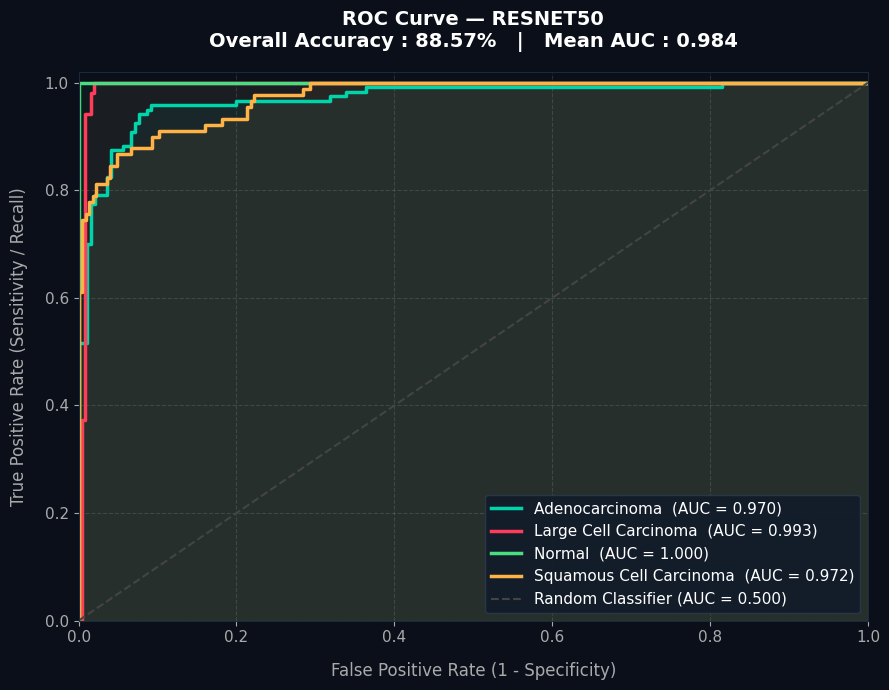


RESNET50
─────────────────────────────────────────────
  Adenocarcinoma            AUC = 0.970  █████████████████████████████
  Large Cell Carcinoma      AUC = 0.993  █████████████████████████████
  Normal                    AUC = 1.000  ██████████████████████████████
  Squamous Cell Carcinoma   AUC = 0.972  █████████████████████████████
  Mean AUC                  AUC = 0.984
─────────────────────────────────────────────


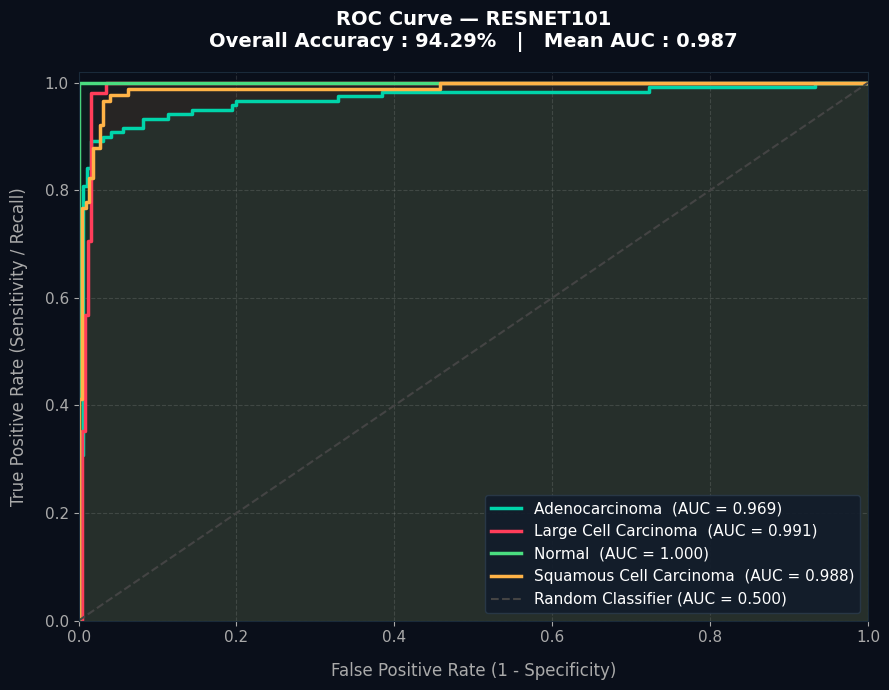


RESNET101
─────────────────────────────────────────────
  Adenocarcinoma            AUC = 0.969  █████████████████████████████
  Large Cell Carcinoma      AUC = 0.991  █████████████████████████████
  Normal                    AUC = 1.000  ██████████████████████████████
  Squamous Cell Carcinoma   AUC = 0.988  █████████████████████████████
  Mean AUC                  AUC = 0.987
─────────────────────────────────────────────


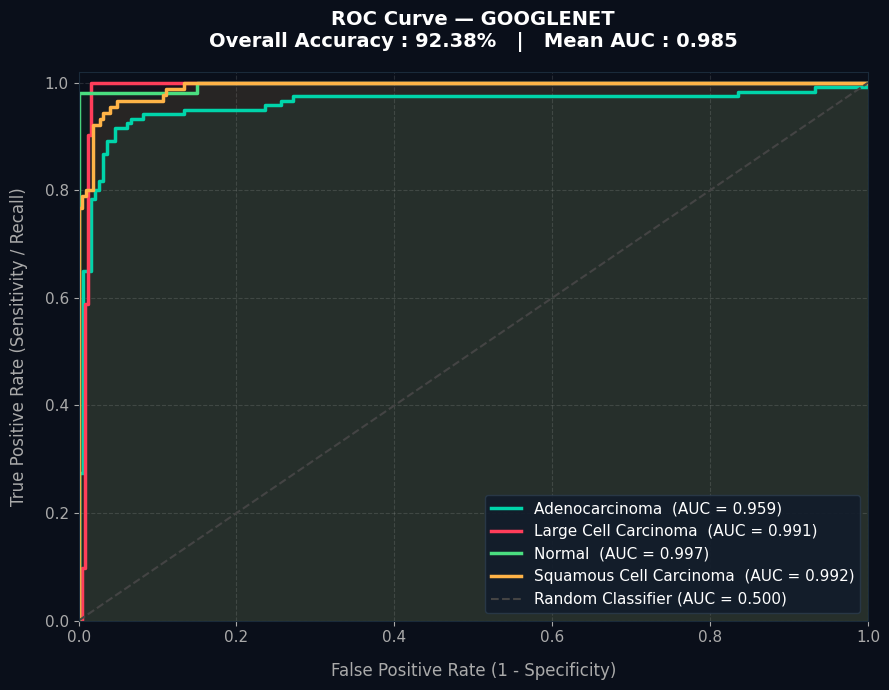


GOOGLENET
─────────────────────────────────────────────
  Adenocarcinoma            AUC = 0.959  ████████████████████████████
  Large Cell Carcinoma      AUC = 0.991  █████████████████████████████
  Normal                    AUC = 0.997  █████████████████████████████
  Squamous Cell Carcinoma   AUC = 0.992  █████████████████████████████
  Mean AUC                  AUC = 0.985
─────────────────────────────────────────────


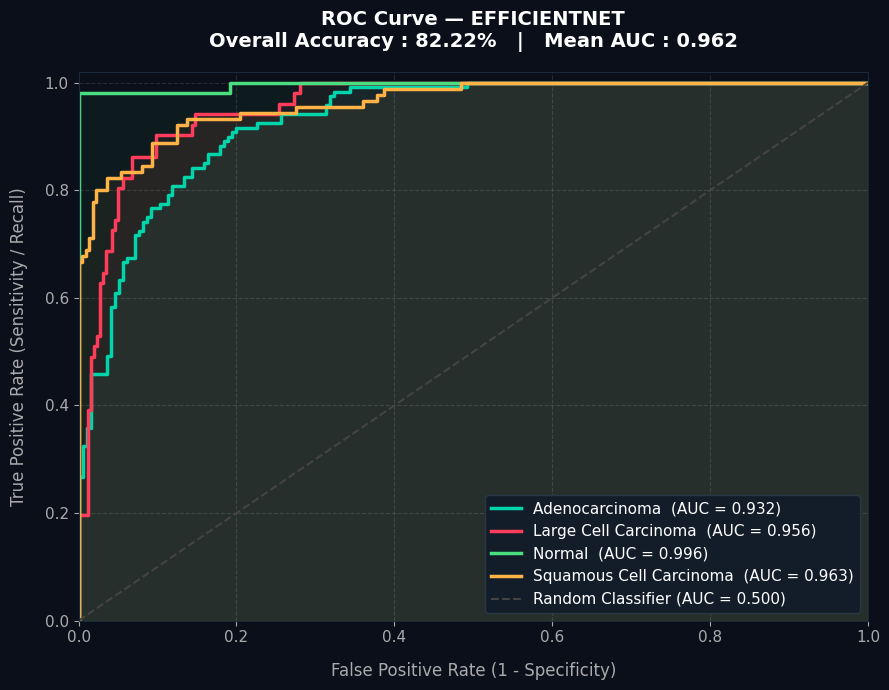


EFFICIENTNET
─────────────────────────────────────────────
  Adenocarcinoma            AUC = 0.932  ███████████████████████████
  Large Cell Carcinoma      AUC = 0.956  ████████████████████████████
  Normal                    AUC = 0.996  █████████████████████████████
  Squamous Cell Carcinoma   AUC = 0.963  ████████████████████████████
  Mean AUC                  AUC = 0.962
─────────────────────────────────────────────

ROC files saved :
  ROC_resnet50.png
  ROC_resnet101.png
  ROC_googlenet.png
  ROC_efficientnet.png


In [ ]:
print("Plotting ROC Curves — One per Model...")
print("=" * 55)

CLS_COLORS  = ['#00d4aa', '#ff3d5a', '#4ade80', '#ffb347']
SHORT_NAMES = [
    "Adenocarcinoma",
    "Large Cell Carcinoma",
    "Normal",
    "Squamous Cell Carcinoma"
]

for name in MODEL_NAMES:

    r   = eval_results[name]
    y_b = label_binarize(r["labels"], classes=list(range(4)))

    fig, ax = plt.subplots(figsize=(9, 7))
    fig.patch.set_facecolor('#0a0f1a')
    ax.set_facecolor('#0a0f1a')

    auc_scores = []

    for i, (cls, col) in enumerate(zip(SHORT_NAMES, CLS_COLORS)):
        fpr, tpr, _ = roc_curve(y_b[:, i], r["probs"][:, i])
        roc_auc     = auc(fpr, tpr)
        auc_scores.append(roc_auc)

        ax.plot(
            fpr, tpr,
            color=col,
            linewidth=2.5,
            label=f"{cls}  (AUC = {roc_auc:.3f})"
        )

        # Fill under curve
        ax.fill_between(
            fpr, tpr,
            alpha=0.06,
            color=col
        )

    # Random classifier line
    ax.plot(
        [0, 1], [0, 1],
        color='#444444',
        linestyle='--',
        linewidth=1.5,
        label='Random Classifier (AUC = 0.500)'
    )

    # Grid
    ax.grid(
        True,
        alpha=0.12,
        color='white',
        linestyle='--'
    )

    # Labels and title
    ax.set_xlabel(
        "False Positive Rate (1 - Specificity)",
        fontsize=12,
        color='#aaaaaa',
        labelpad=12
    )
    ax.set_ylabel(
        "True Positive Rate (Sensitivity / Recall)",
        fontsize=12,
        color='#aaaaaa',
        labelpad=12
    )
    ax.set_title(
        f"ROC Curve — {name.upper()}\n"
        f"Overall Accuracy : {r['acc']:.2f}%   |   "
        f"Mean AUC : {np.mean(auc_scores):.3f}",
        fontsize=14,
        fontweight='bold',
        color='white',
        pad=18
    )

    ax.tick_params(colors='#aaaaaa', labelsize=11)
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.02])

    ax.spines['top'].set_color('#1a2a3a')
    ax.spines['right'].set_color('#1a2a3a')
    ax.spines['left'].set_color('#1a2a3a')
    ax.spines['bottom'].set_color('#1a2a3a')

    legend = ax.legend(
        fontsize=11,
        facecolor='#111b2a',
        edgecolor='#2a3a4a',
        labelcolor='white',
        loc='lower right',
        framealpha=0.9
    )

    plt.tight_layout()
    plt.savefig(
        f"ROC_{name}.png",
        dpi=150,
        bbox_inches='tight',
        facecolor='#0a0f1a'
    )
    plt.show()
    plt.close()

    # Print AUC scores
    print(f"\n{name.upper()}")
    print(f"{'─' * 45}")
    for cls, sc in zip(SHORT_NAMES, auc_scores):
        bar = '█' * int(sc * 30)
        print(f"  {cls:<25} AUC = {sc:.3f}  {bar}")
    print(f"  {'Mean AUC':<25} AUC = {np.mean(auc_scores):.3f}")
    print(f"{'─' * 45}")

print("\nROC files saved :")
for name in MODEL_NAMES:
    print(f"  ROC_{name}.png")

Plotting Precision Recall F1 — One per Model...


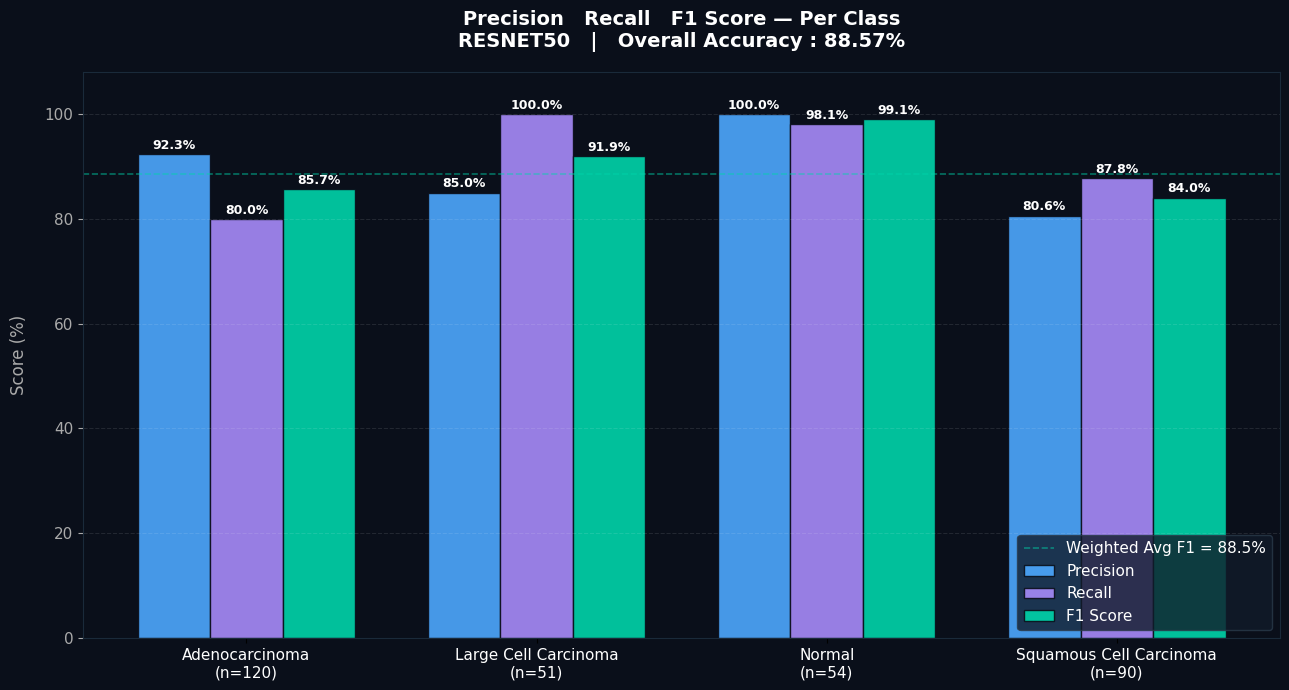


  RESNET50
  Class                      Precision   Recall       F1  Support
  ───────────────────────────────────────────────────────
  Adenocarcinoma                 92.3%    80.0%    85.7%
  Large Cell Carcinoma           85.0%   100.0%    91.9%
  Normal                        100.0%    98.1%    99.1%
  Squamous Cell Carcinoma        80.6%    87.8%    84.0%
  ───────────────────────────────────────────────────────
  Weighted Average               89.1%    88.6%    88.5%
  Overall Accuracy              88.57%



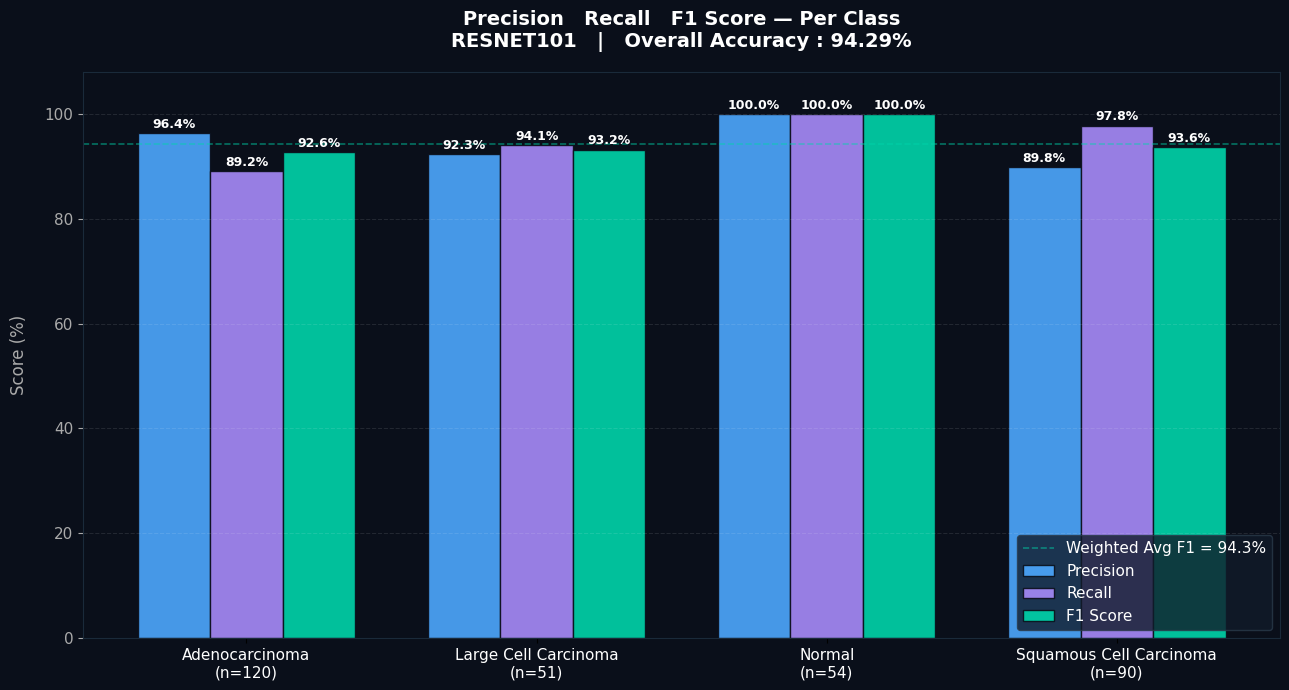


  RESNET101
  Class                      Precision   Recall       F1  Support
  ───────────────────────────────────────────────────────
  Adenocarcinoma                 96.4%    89.2%    92.6%
  Large Cell Carcinoma           92.3%    94.1%    93.2%
  Normal                        100.0%   100.0%   100.0%
  Squamous Cell Carcinoma        89.8%    97.8%    93.6%
  ───────────────────────────────────────────────────────
  Weighted Average               94.5%    94.3%    94.3%
  Overall Accuracy              94.29%



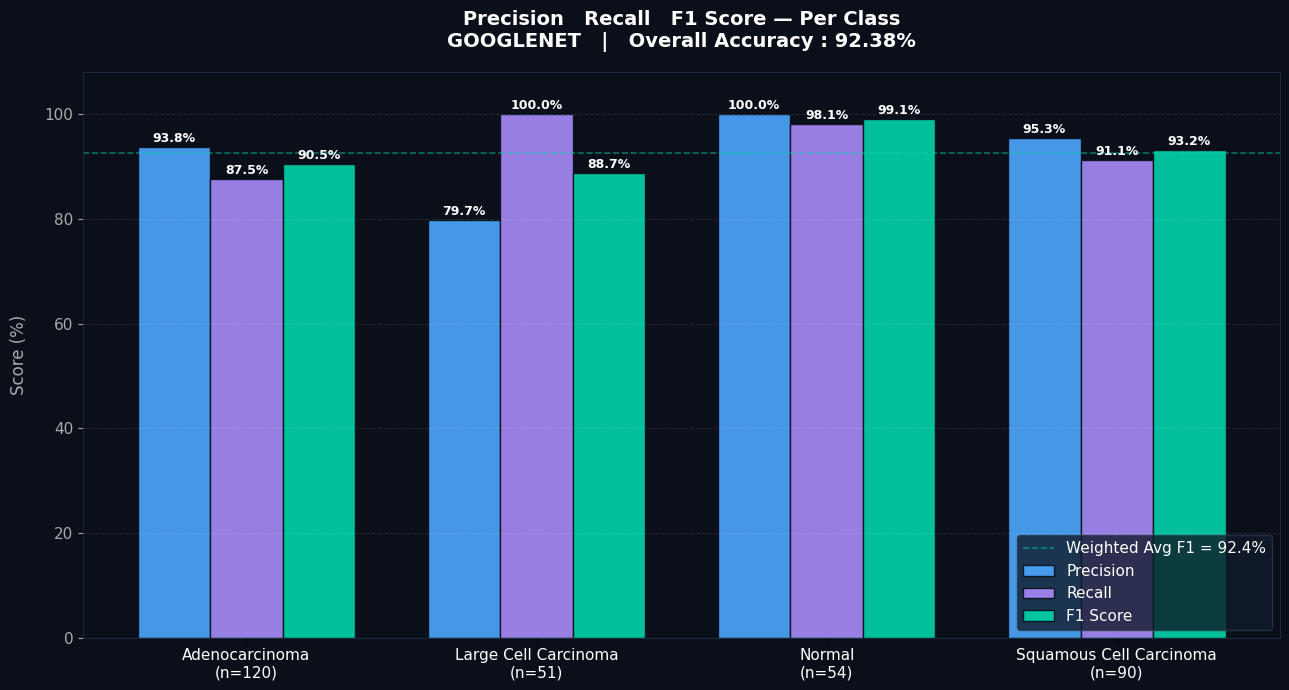


  GOOGLENET
  Class                      Precision   Recall       F1  Support
  ───────────────────────────────────────────────────────
  Adenocarcinoma                 93.8%    87.5%    90.5%
  Large Cell Carcinoma           79.7%   100.0%    88.7%
  Normal                        100.0%    98.1%    99.1%
  Squamous Cell Carcinoma        95.3%    91.1%    93.2%
  ───────────────────────────────────────────────────────
  Weighted Average               93.0%    92.4%    92.4%
  Overall Accuracy              92.38%



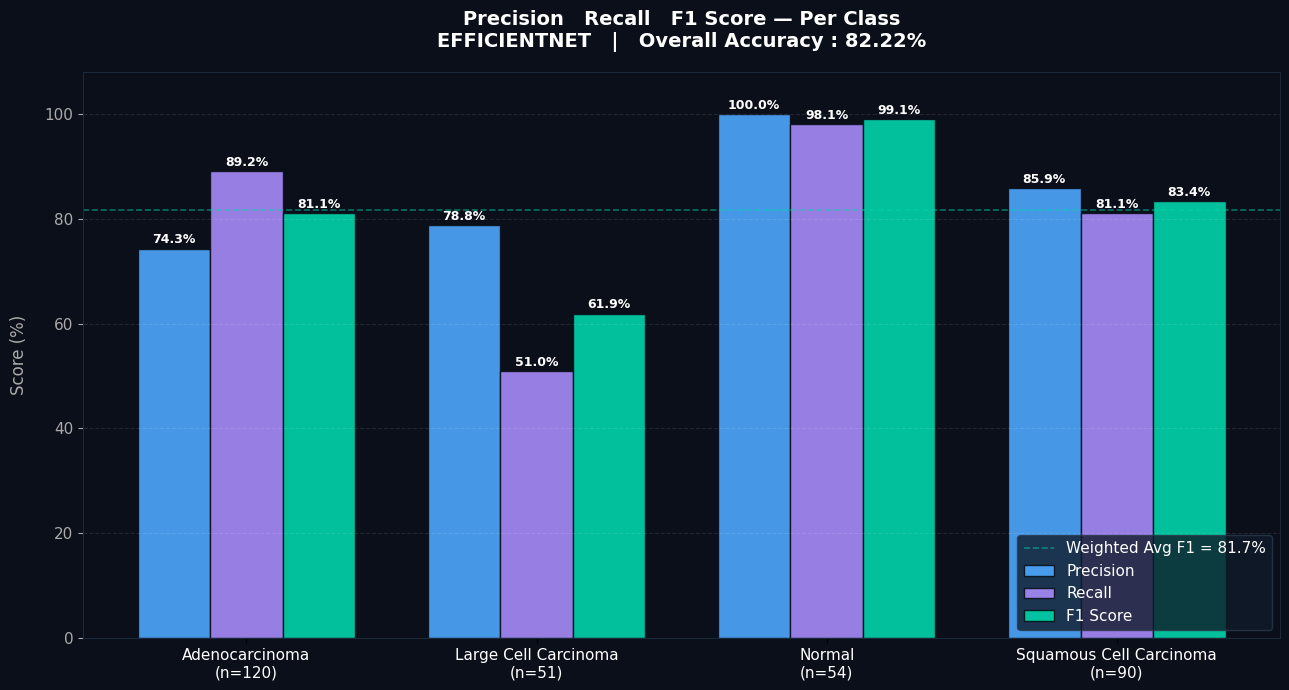


  EFFICIENTNET
  Class                      Precision   Recall       F1  Support
  ───────────────────────────────────────────────────────
  Adenocarcinoma                 74.3%    89.2%    81.1%
  Large Cell Carcinoma           78.8%    51.0%    61.9%
  Normal                        100.0%    98.1%    99.1%
  Squamous Cell Carcinoma        85.9%    81.1%    83.4%
  ───────────────────────────────────────────────────────
  Weighted Average               82.7%    82.2%    81.7%
  Overall Accuracy              82.22%

Precision Recall F1 files saved :
  PRF1_resnet50.png
  PRF1_resnet101.png
  PRF1_googlenet.png
  PRF1_efficientnet.png


In [ ]:
print("Plotting Precision Recall F1 — One per Model...")
print("=" * 55)

METRIC_COLORS = {
    "Precision" : '#4da8ff',
    "Recall"    : '#a78bfa',
    "F1 Score"  : '#00d4aa'
}

for name in MODEL_NAMES:

    r   = eval_results[name]
    rep = classification_report(
        r["labels"],
        r["preds"],
        target_names=SHORT_NAMES,
        output_dict=True
    )

    # Extract per-class values
    precisions = [rep[cls]["precision"] * 100 for cls in SHORT_NAMES]
    recalls    = [rep[cls]["recall"]    * 100 for cls in SHORT_NAMES]
    f1s        = [rep[cls]["f1-score"]  * 100 for cls in SHORT_NAMES]
    supports   = [int(rep[cls]["support"]) for cls in SHORT_NAMES]

    x     = np.arange(len(SHORT_NAMES))
    width = 0.25

    fig, ax = plt.subplots(figsize=(13, 7))
    fig.patch.set_facecolor('#0a0f1a')
    ax.set_facecolor('#0a0f1a')

    # Draw 3 bars per class
    b1 = ax.bar(
        x - width, precisions,
        width,
        label='Precision',
        color='#4da8ff',
        alpha=0.9,
        edgecolor='#0a0f1a',
        linewidth=1
    )
    b2 = ax.bar(
        x,         recalls,
        width,
        label='Recall',
        color='#a78bfa',
        alpha=0.9,
        edgecolor='#0a0f1a',
        linewidth=1
    )
    b3 = ax.bar(
        x + width, f1s,
        width,
        label='F1 Score',
        color='#00d4aa',
        alpha=0.9,
        edgecolor='#0a0f1a',
        linewidth=1
    )

    # Value labels on top of each bar
    for bars in [b1, b2, b3]:
        for bar in bars:
            height = bar.get_height()
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                height + 0.4,
                f'{height:.1f}%',
                ha='center',
                va='bottom',
                fontsize=9,
                fontweight='bold',
                color='white'
            )

    # Support count below x-axis labels
    support_labels = [
        f"{sn}\n(n={sup})"
        for sn, sup in zip(SHORT_NAMES, supports)
    ]

    ax.set_xticks(x)
    ax.set_xticklabels(
        support_labels,
        fontsize=11,
        color='white'
    )
    ax.tick_params(axis='y', colors='#aaaaaa', labelsize=11)

    ax.set_ylim(0, 108)
    ax.set_ylabel(
        "Score (%)",
        fontsize=12,
        color='#aaaaaa',
        labelpad=12
    )
    ax.set_title(
        f"Precision   Recall   F1 Score — Per Class\n"
        f"{name.upper()}   |   Overall Accuracy : {r['acc']:.2f}%",
        fontsize=14,
        fontweight='bold',
        color='white',
        pad=18
    )

    # Weighted averages line
    w_prec = rep['weighted avg']['precision'] * 100
    w_rec  = rep['weighted avg']['recall']    * 100
    w_f1   = rep['weighted avg']['f1-score']  * 100

    ax.axhline(
        y=w_f1,
        color='#00d4aa',
        linestyle='--',
        linewidth=1.2,
        alpha=0.5,
        label=f"Weighted Avg F1 = {w_f1:.1f}%"
    )

    ax.spines['top'].set_color('#1a2a3a')
    ax.spines['right'].set_color('#1a2a3a')
    ax.spines['left'].set_color('#1a2a3a')
    ax.spines['bottom'].set_color('#1a2a3a')
    ax.grid(
        axis='y',
        alpha=0.1,
        color='white',
        linestyle='--'
    )

    legend = ax.legend(
        fontsize=11,
        facecolor='#111b2a',
        edgecolor='#2a3a4a',
        labelcolor='white',
        loc='lower right'
    )

    plt.tight_layout()
    plt.savefig(
        f"PRF1_{name}.png",
        dpi=150,
        bbox_inches='tight',
        facecolor='#0a0f1a'
    )
    plt.show()
    plt.close()

    # Print detailed report
    print(f"\n{'=' * 58}")
    print(f"  {name.upper()}")
    print(f"{'=' * 58}")
    print(f"  {'Class':<25} {'Precision':>10} {'Recall':>8} "
          f"{'F1':>8} {'Support':>8}")
    print(f"  {'─' * 55}")
    for cls, p, rec, f in zip(SHORT_NAMES,
                               precisions, recalls, f1s):
        print(f"  {cls:<25} {p:>9.1f}% {rec:>7.1f}% "
              f"{f:>7.1f}%")
    print(f"  {'─' * 55}")
    print(f"  {'Weighted Average':<25} {w_prec:>9.1f}% "
          f"{w_rec:>7.1f}% {w_f1:>7.1f}%")
    print(f"  {'Overall Accuracy':<25} {r['acc']:>9.2f}%")
    print(f"{'=' * 58}\n")

print("Precision Recall F1 files saved :")
for name in MODEL_NAMES:
    print(f"  PRF1_{name}.png")

Plotting Model Accuracy Comparison...


/tmp/ipykernel_11364/3681305732.py:95: UserWarning: Glyph 128081 (\N{CROWN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_11364/3681305732.py:96: UserWarning: Glyph 128081 (\N{CROWN}) missing from font(s) DejaVu Sans.
  plt.savefig(
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128081 (\N{CROWN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


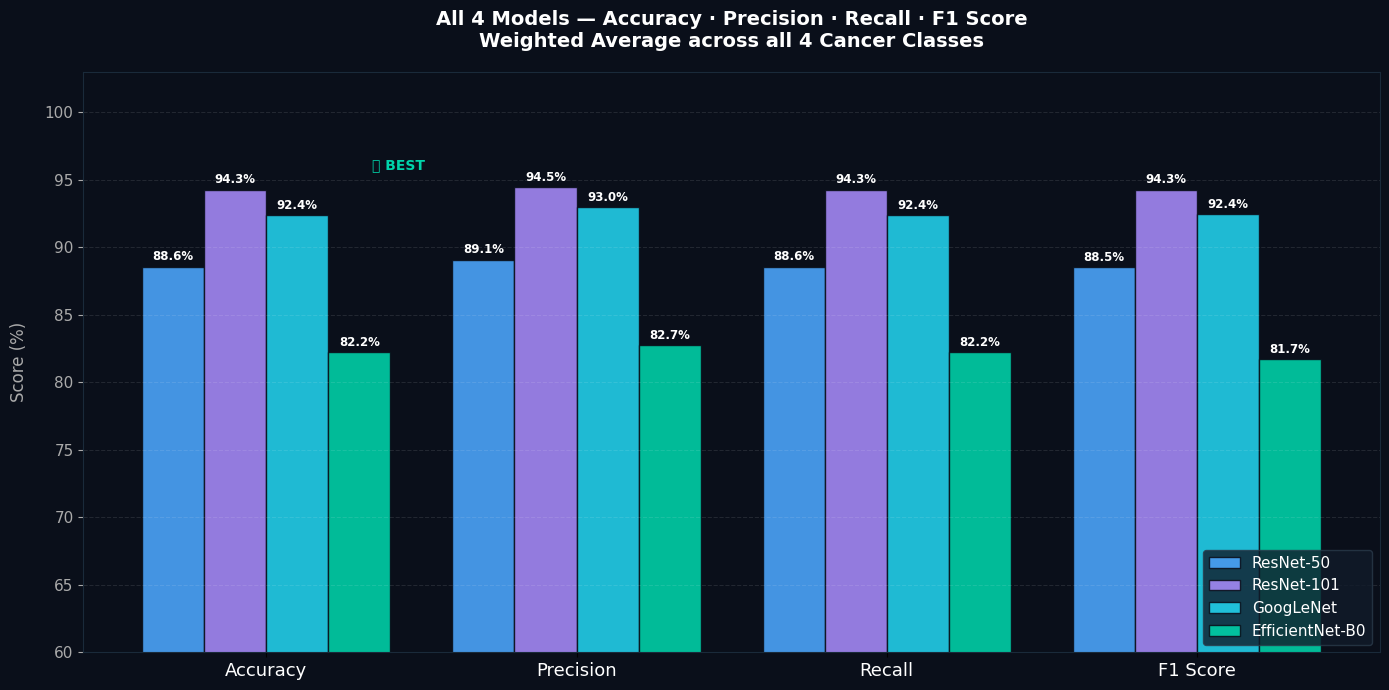


  FINAL MODEL COMPARISON SUMMARY
  Model               Accuracy  Precision   Recall       F1
  ──────────────────────────────────────────────────────────
  ResNet-50             88.57%     89.10%   88.57%   88.53%
  ResNet-101            94.29%     94.47%   94.29%   94.27% <-- BEST
  GoogLeNet             92.38%     93.00%   92.38%   92.45%
  EfficientNet-B0       82.22%     82.74%   82.22%   81.72%
Saved as ModelComparison_AllMetrics.png


In [ ]:
print("Plotting Model Accuracy Comparison...")

MODEL_LABELS  = ['ResNet-50', 'ResNet-101', 'GoogLeNet', 'EfficientNet-B0']
MODEL_COLORS  = ['#4da8ff',   '#a78bfa',    '#22d3ee',   '#00d4aa']
METRIC_KEYS   = ["Accuracy", "Precision", "Recall", "F1 Score"]

# Collect metrics
all_metrics = {}
for name in MODEL_NAMES:
    r   = eval_results[name]
    rep = classification_report(
        r["labels"], r["preds"],
        target_names=SHORT_NAMES,
        output_dict=True
    )
    all_metrics[name] = {
        "Accuracy"  : r["acc"],
        "Precision" : rep['weighted avg']['precision'] * 100,
        "Recall"    : rep['weighted avg']['recall']    * 100,
        "F1 Score"  : rep['weighted avg']['f1-score']  * 100
    }

x     = np.arange(len(METRIC_KEYS))
width = 0.2

fig, ax = plt.subplots(figsize=(14, 7))
fig.patch.set_facecolor('#0a0f1a')
ax.set_facecolor('#0a0f1a')

for i, (name, label, col) in enumerate(
    zip(MODEL_NAMES, MODEL_LABELS, MODEL_COLORS)
):
    vals = [all_metrics[name][m] for m in METRIC_KEYS]
    bars = ax.bar(
        x + i * width, vals,
        width,
        label=label,
        color=col,
        alpha=0.88,
        edgecolor='#0a0f1a',
        linewidth=1
    )
    for bar, val in zip(bars, vals):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.25,
            f'{val:.1f}%',
            ha='center',
            va='bottom',
            fontsize=8.5,
            fontweight='bold',
            color='white'
        )

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(METRIC_KEYS, fontsize=13, color='white')
ax.tick_params(axis='y', colors='#aaaaaa', labelsize=11)
ax.set_ylim(60, 103)
ax.set_ylabel("Score (%)", fontsize=12, color='#aaaaaa', labelpad=12)
ax.set_title(
    "All 4 Models — Accuracy · Precision · Recall · F1 Score\n"
    "Weighted Average across all 4 Cancer Classes",
    fontsize=14,
    fontweight='bold',
    color='white',
    pad=18
)

ax.spines['top'].set_color('#1a2a3a')
ax.spines['right'].set_color('#1a2a3a')
ax.spines['left'].set_color('#1a2a3a')
ax.spines['bottom'].set_color('#1a2a3a')
ax.grid(axis='y', alpha=0.1, color='white', linestyle='--')

legend = ax.legend(
    fontsize=11,
    facecolor='#111b2a',
    edgecolor='#2a3a4a',
    labelcolor='white',
    loc='lower right'
)

# Crown on best model
best_name = max(MODEL_NAMES, key=lambda n: all_metrics[n]["Accuracy"])
best_idx  = MODEL_NAMES.index(best_name)
ax.text(
    x[0] + best_idx * width + width * 2.2,
    all_metrics[best_name]["Accuracy"] + 1.5,
    "👑 BEST",
    fontsize=10,
    color='#00d4aa',
    fontweight='bold'
)

plt.tight_layout()
plt.savefig(
    "ModelComparison_AllMetrics.png",
    dpi=150,
    bbox_inches='tight',
    facecolor='#0a0f1a'
)
plt.show()
plt.close()

# Print summary table
print(f"\n{'=' * 62}")
print(f"  FINAL MODEL COMPARISON SUMMARY")
print(f"{'=' * 62}")
print(f"  {'Model':<18} {'Accuracy':>9} {'Precision':>10} "
      f"{'Recall':>8} {'F1':>8}")
print(f"  {'─' * 58}")
for name, label in zip(MODEL_NAMES, MODEL_LABELS):
    m      = all_metrics[name]
    crown  = " <-- BEST" if name == best_name else ""
    print(f"  {label:<18} {m['Accuracy']:>8.2f}% "
          f"{m['Precision']:>9.2f}% "
          f"{m['Recall']:>7.2f}% "
          f"{m['F1 Score']:>7.2f}%{crown}")
print(f"{'=' * 62}")
print("Saved as ModelComparison_AllMetrics.png")

Plotting Training Curves — One per Model...


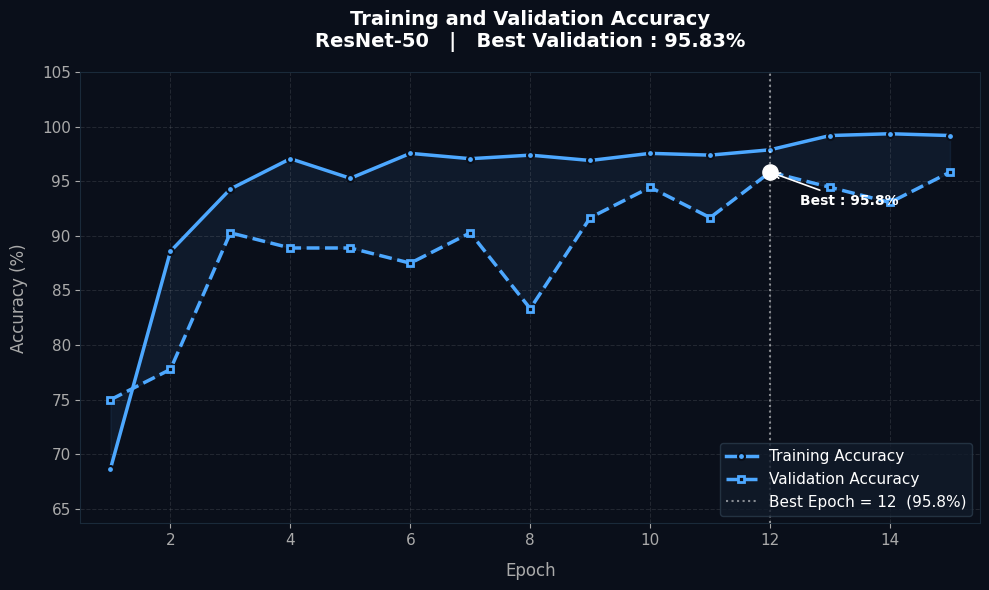

  ResNet-50          | Best Val : 95.83%  at Epoch 12


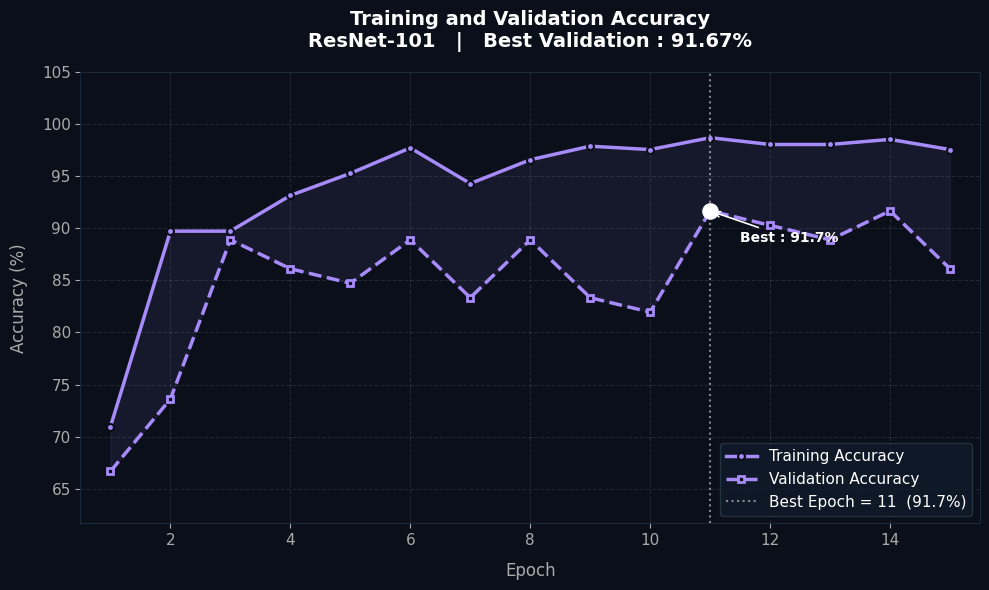

  ResNet-101         | Best Val : 91.67%  at Epoch 11


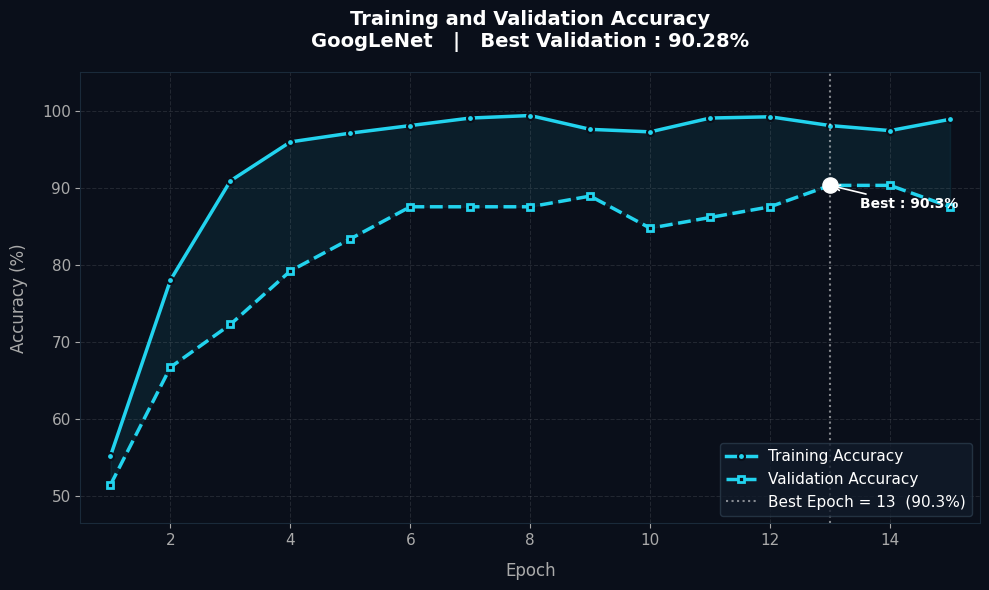

  GoogLeNet          | Best Val : 90.28%  at Epoch 13


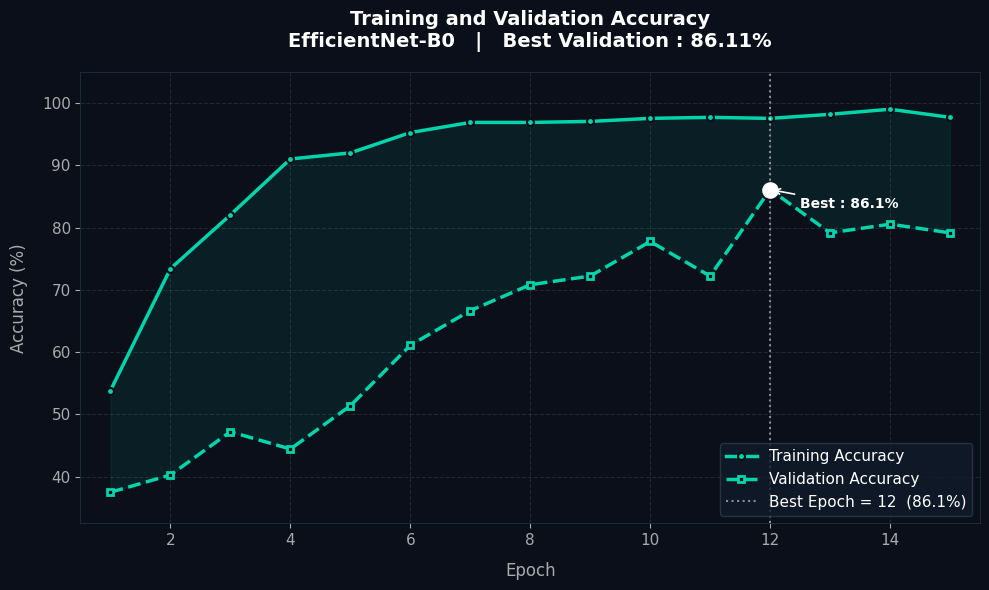

  EfficientNet-B0    | Best Val : 86.11%  at Epoch 12

Training Curve files saved :
  TrainingCurve_resnet50.png
  TrainingCurve_resnet101.png
  TrainingCurve_googlenet.png
  TrainingCurve_efficientnet.png


In [ ]:
print("Plotting Training Curves — One per Model...")

MODEL_LABELS = ['ResNet-50', 'ResNet-101', 'GoogLeNet', 'EfficientNet-B0']
MODEL_COLORS = ['#4da8ff',   '#a78bfa',    '#22d3ee',   '#00d4aa']

for name, label, col in zip(MODEL_NAMES, MODEL_LABELS, MODEL_COLORS):

    t_h, v_h = histories[name]
    epochs   = list(range(1, len(t_h) + 1))
    best_ep  = v_h.index(max(v_h)) + 1
    best_val = max(v_h)

    fig, ax = plt.subplots(figsize=(10, 6))
    fig.patch.set_facecolor('#0a0f1a')
    ax.set_facecolor('#0a0f1a')

    # Train line
    ax.plot(
        epochs, t_h,
        color=col,
        linewidth=2.5,
        label=f'Training Accuracy',
        marker='o',
        markersize=5,
        markerfacecolor=col,
        markeredgecolor='#0a0f1a',
        markeredgewidth=1.5
    )

    # Validation line
    ax.plot(
        epochs, v_h,
        color=col,
        linewidth=2.5,
        linestyle='--',
        label=f'Validation Accuracy',
        marker='s',
        markersize=5,
        markerfacecolor='#0a0f1a',
        markeredgecolor=col,
        markeredgewidth=2
    )

    # Fill between train and val
    ax.fill_between(
        epochs, t_h, v_h,
        alpha=0.08,
        color=col
    )

    # Best epoch marker
    ax.axvline(
        x=best_ep,
        color='white',
        linestyle=':',
        linewidth=1.5,
        alpha=0.5,
        label=f'Best Epoch = {best_ep}  ({best_val:.1f}%)'
    )
    ax.scatter(
        [best_ep], [best_val],
        color='white',
        s=120,
        zorder=5
    )
    ax.annotate(
        f"Best : {best_val:.1f}%",
        xy=(best_ep, best_val),
        xytext=(best_ep + 0.5, best_val - 3),
        fontsize=10,
        color='white',
        fontweight='bold',
        arrowprops=dict(
            arrowstyle='->',
            color='white',
            lw=1.2
        )
    )

    ax.set_xlim(0.5, len(epochs) + 0.5)
    ax.set_ylim(
        min(min(t_h), min(v_h)) - 5,
        105
    )
    ax.set_xlabel(
        "Epoch",
        fontsize=12,
        color='#aaaaaa',
        labelpad=10
    )
    ax.set_ylabel(
        "Accuracy (%)",
        fontsize=12,
        color='#aaaaaa',
        labelpad=10
    )
    ax.set_title(
        f"Training and Validation Accuracy\n"
        f"{label}   |   Best Validation : {best_val:.2f}%",
        fontsize=14,
        fontweight='bold',
        color='white',
        pad=18
    )

    ax.tick_params(colors='#aaaaaa', labelsize=11)
    ax.spines['top'].set_color('#1a2a3a')
    ax.spines['right'].set_color('#1a2a3a')
    ax.spines['left'].set_color('#1a2a3a')
    ax.spines['bottom'].set_color('#1a2a3a')
    ax.grid(
        True,
        alpha=0.1,
        color='white',
        linestyle='--'
    )

    legend = ax.legend(
        fontsize=11,
        facecolor='#111b2a',
        edgecolor='#2a3a4a',
        labelcolor='white',
        loc='lower right'
    )

    plt.tight_layout()
    plt.savefig(
        f"TrainingCurve_{name}.png",
        dpi=150,
        bbox_inches='tight',
        facecolor='#0a0f1a'
    )
    plt.show()
    plt.close()

    print(f"  {label:<18} | Best Val : {best_val:.2f}%  "
          f"at Epoch {best_ep}")

print("\nTraining Curve files saved :")
for name in MODEL_NAMES:
    print(f"  TrainingCurve_{name}.png")

# --- COMMENTED OUT: The following markdown section caused a SyntaxError. ---
# ## Complete List of All Images Generated
# ```
# Cell 11 — Confusion Matrix (8 files)
#   CM_resnet50.png
#   CM_resnet101.png
#   CM_googlenet.png
#   CM_efficientnet.png
#   PerClass_resnet50.png
#   PerClass_resnet101.png
#   PerClass_googlenet.png
#   PerClass_efficientnet.png

# Cell 12 — ROC Curves (4 files)
#   ROC_resnet50.png
#   ROC_resnet101.png
#   ROC_googlenet.png
#   ROC_efficientnet.png

# Cell 13 — Precision Recall F1 (4 files)
#   PRF1_resnet50.png
#   PRF1_resnet101.png
#   PRF1_googlenet.png
#   PRF1_efficientnet.png

# Cell 14 — All Models Comparison (1 file)
#   ModelComparison_AllMetrics.png

# Cell 15 — Training Curves (4 files)
#   TrainingCurve_resnet50.png
#   TrainingCurve_resnet101.png
#   TrainingCurve_googlenet.png
#   TrainingCurve_efficientnet.png

# Total : 21 separate clean images
# ```

Plotting Training Curves — One per Model...


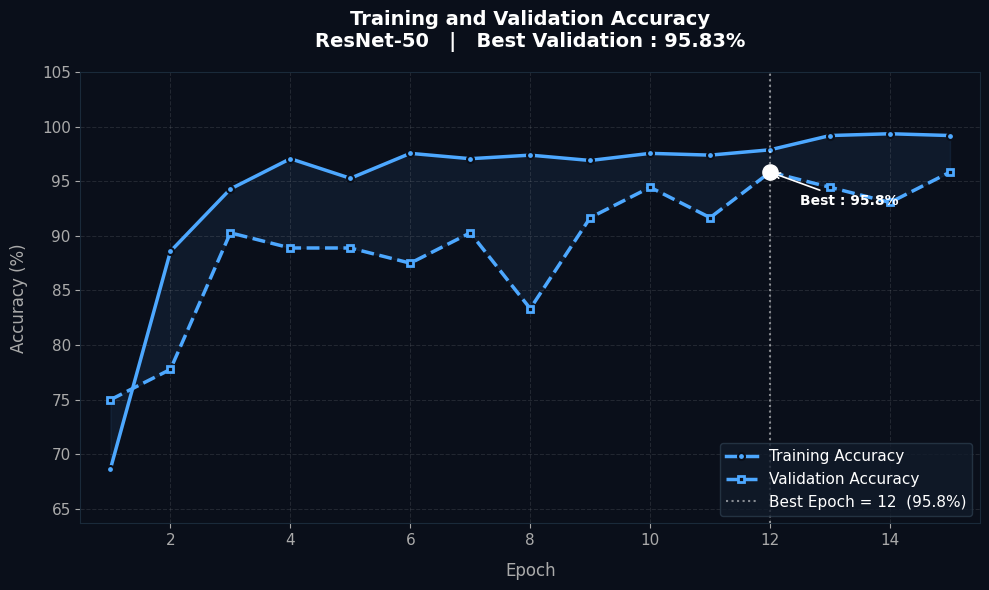

  ResNet-50          | Best Val : 95.83%  at Epoch 12


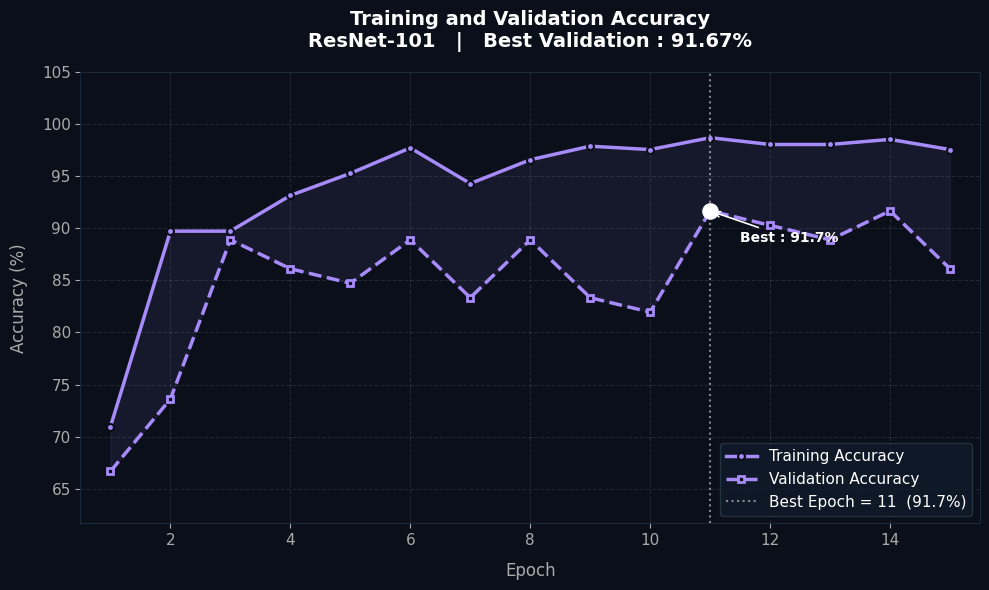

  ResNet-101         | Best Val : 91.67%  at Epoch 11


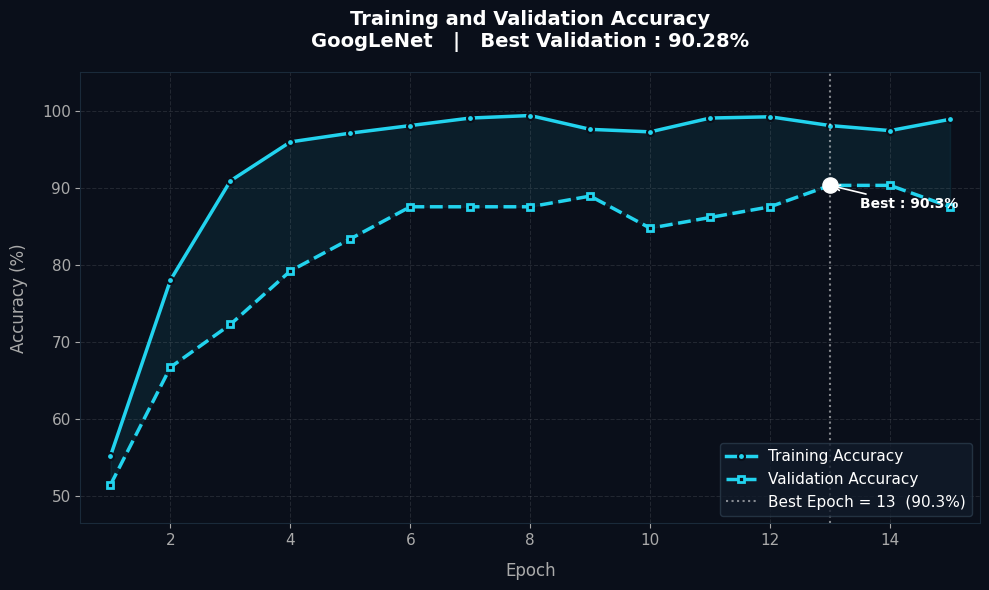

  GoogLeNet          | Best Val : 90.28%  at Epoch 13


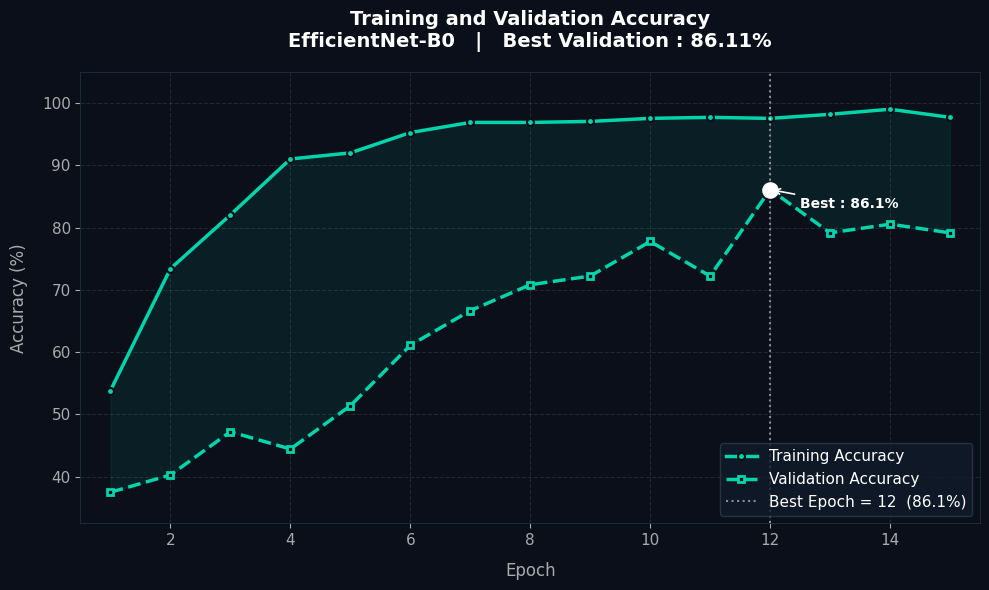

  EfficientNet-B0    | Best Val : 86.11%  at Epoch 12

Training Curve files saved :
  TrainingCurve_resnet50.png
  TrainingCurve_resnet101.png
  TrainingCurve_googlenet.png
  TrainingCurve_efficientnet.png


In [ ]:
print("Plotting Training Curves — One per Model...")

MODEL_LABELS = ['ResNet-50', 'ResNet-101', 'GoogLeNet', 'EfficientNet-B0']
MODEL_COLORS = ['#4da8ff',   '#a78bfa',    '#22d3ee',   '#00d4aa']

for name, label, col in zip(MODEL_NAMES, MODEL_LABELS, MODEL_COLORS):

    t_h, v_h = histories[name]
    epochs   = list(range(1, len(t_h) + 1))
    best_ep  = v_h.index(max(v_h)) + 1
    best_val = max(v_h)

    fig, ax = plt.subplots(figsize=(10, 6))
    fig.patch.set_facecolor('#0a0f1a')
    ax.set_facecolor('#0a0f1a')

    # Train line
    ax.plot(
        epochs, t_h,
        color=col,
        linewidth=2.5,
        label=f'Training Accuracy',
        marker='o',
        markersize=5,
        markerfacecolor=col,
        markeredgecolor='#0a0f1a',
        markeredgewidth=1.5
    )

    # Validation line
    ax.plot(
        epochs, v_h,
        color=col,
        linewidth=2.5,
        linestyle='--',
        label=f'Validation Accuracy',
        marker='s',
        markersize=5,
        markerfacecolor='#0a0f1a',
        markeredgecolor=col,
        markeredgewidth=2
    )

    # Fill between train and val
    ax.fill_between(
        epochs, t_h, v_h,
        alpha=0.08,
        color=col
    )

    # Best epoch marker
    ax.axvline(
        x=best_ep,
        color='white',
        linestyle=':',
        linewidth=1.5,
        alpha=0.5,
        label=f'Best Epoch = {best_ep}  ({best_val:.1f}%)'
    )
    ax.scatter(
        [best_ep], [best_val],
        color='white',
        s=120,
        zorder=5
    )
    ax.annotate(
        f"Best : {best_val:.1f}%",
        xy=(best_ep, best_val),
        xytext=(best_ep + 0.5, best_val - 3),
        fontsize=10,
        color='white',
        fontweight='bold',
        arrowprops=dict(
            arrowstyle='->',
            color='white',
            lw=1.2
        )
    )

    ax.set_xlim(0.5, len(epochs) + 0.5)
    ax.set_ylim(
        min(min(t_h), min(v_h)) - 5,
        105
    )
    ax.set_xlabel(
        "Epoch",
        fontsize=12,
        color='#aaaaaa',
        labelpad=10
    )
    ax.set_ylabel(
        "Accuracy (%)",
        fontsize=12,
        color='#aaaaaa',
        labelpad=10
    )
    ax.set_title(
        f"Training and Validation Accuracy\n"
        f"{label}   |   Best Validation : {best_val:.2f}%",
        fontsize=14,
        fontweight='bold',
        color='white',
        pad=18
    )

    ax.tick_params(colors='#aaaaaa', labelsize=11)
    ax.spines['top'].set_color('#1a2a3a')
    ax.spines['right'].set_color('#1a2a3a')
    ax.spines['left'].set_color('#1a2a3a')
    ax.spines['bottom'].set_color('#1a2a3a')
    ax.grid(
        True,
        alpha=0.1,
        color='white',
        linestyle='--'
    )

    legend = ax.legend(
        fontsize=11,
        facecolor='#111b2a',
        edgecolor='#2a3a4a',
        labelcolor='white',
        loc='lower right'
    )

    plt.tight_layout()
    plt.savefig(
        f"TrainingCurve_{name}.png",
        dpi=150,
        bbox_inches='tight',
        facecolor='#0a0f1a'
    )
    plt.show()
    plt.close()

    print(f"  {label:<18} | Best Val : {best_val:.2f}%  "
          f"at Epoch {best_ep}")

print("\nTraining Curve files saved :")
for name in MODEL_NAMES:
    print(f"  TrainingCurve_{name}.png")

# --- COMMENTED OUT: The following markdown section caused a SyntaxError. ---
# ## Complete List of All Images Generated
# ```
# Cell 11 — Confusion Matrix (8 files)
#   CM_resnet50.png
#   CM_resnet101.png
#   CM_googlenet.png
#   CM_efficientnet.png
#   PerClass_resnet50.png
#   PerClass_resnet101.png
#   PerClass_googlenet.png
#   PerClass_efficientnet.png

# Cell 12 — ROC Curves (4 files)
#   ROC_resnet50.png
#   ROC_resnet101.png
#   ROC_googlenet.png
#   ROC_efficientnet.png

# Cell 13 — Precision Recall F1 (4 files)
#   PRF1_resnet50.png
#   PRF1_resnet101.png
#   PRF1_googlenet.png
#   PRF1_efficientnet.png

# Cell 14 — All Models Comparison (1 file)
#   ModelComparison_AllMetrics.png

# Cell 15 — Training Curves (4 files)
#   TrainingCurve_resnet50.png
#   TrainingCurve_resnet101.png
#   TrainingCurve_googlenet.png
#   TrainingCurve_efficientnet.png

# Total : 21 separate clean images
# ```

  COMPLETE CLASSIFICATION REPORT — ALL 4 MODELS

─────────────────────────────────────────────────────────────────
  Model    : RESNET50
  Accuracy : 88.57%
─────────────────────────────────────────────────────────────────
                                                  precision    recall  f1-score   support

      adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib     0.9231    0.8000    0.8571       120
   large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa     0.8500    1.0000    0.9189        51
                                          normal     1.0000    0.9815    0.9907        54
squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa     0.8061    0.8778    0.8404        90

                                        accuracy                         0.8857       315
                                       macro avg     0.8948    0.9148    0.9018       315
                                    weighted avg     0.8910    0.8857    0.8853       315


─────────────────────────────────────────────────────

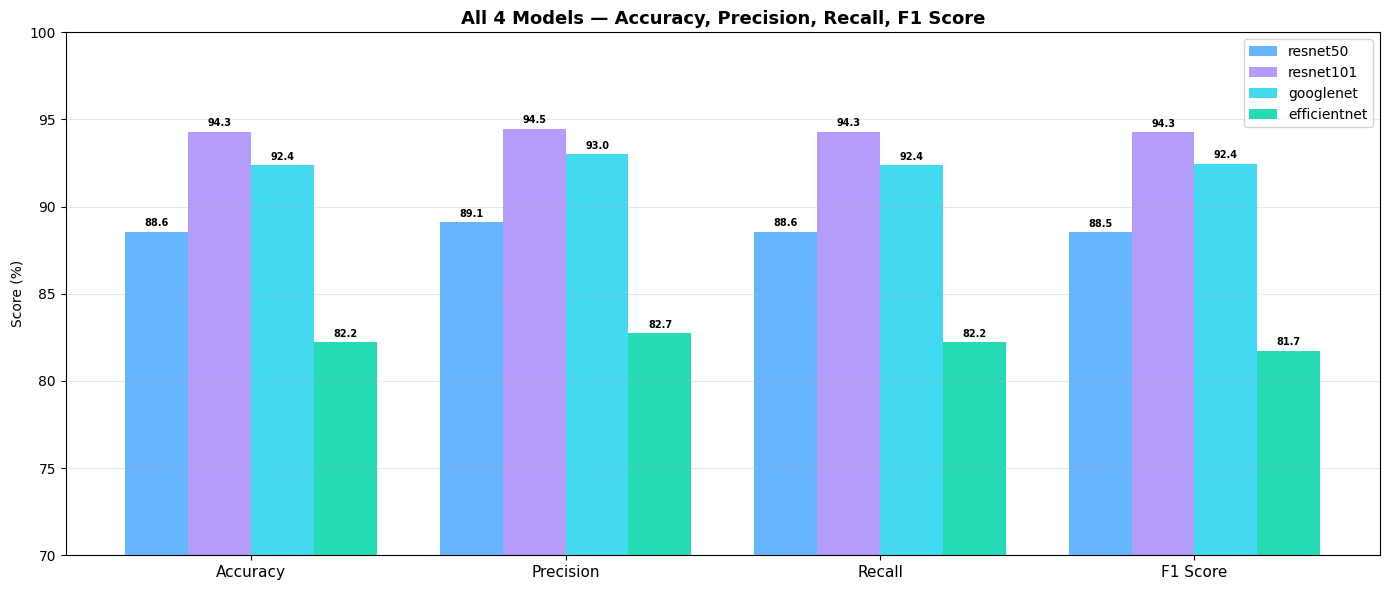

Saved as metrics_comparison.png


In [ ]:
print("=" * 65)
print("  COMPLETE CLASSIFICATION REPORT — ALL 4 MODELS")
print("=" * 65)

for name in MODEL_NAMES:
    r = eval_results[name]
    print(f"\n{'─' * 65}")
    print(f"  Model    : {name.upper()}")
    print(f"  Accuracy : {r['acc']:.2f}%")
    print(f"{'─' * 65}")
    print(classification_report(
        r["labels"],
        r["preds"],
        target_names=CLASS_NAMES,
        digits=4
    ))

# Weighted metrics for comparison
metrics_compare = {}

for name in MODEL_NAMES:
    r = eval_results[name]
    metrics_compare[name] = {
        "Accuracy"  : r["acc"],
        "Precision" : precision_score(
            r["labels"], r["preds"], average='weighted'
        ) * 100,
        "Recall"    : recall_score(
            r["labels"], r["preds"], average='weighted'
        ) * 100,
        "F1 Score"  : f1_score(
            r["labels"], r["preds"], average='weighted'
        ) * 100
    }

# Plot bar chart comparison
metric_names = ["Accuracy", "Precision", "Recall", "F1 Score"]
bar_colors   = ['#4da8ff', '#a78bfa', '#22d3ee', '#00d4aa']
x     = np.arange(len(metric_names))
width = 0.2

fig, ax = plt.subplots(figsize=(14, 6))

for i, (name, col) in enumerate(zip(MODEL_NAMES, bar_colors)):
    vals = [metrics_compare[name][m] for m in metric_names]
    bars = ax.bar(
        x + i * width, vals, width,
        label=name, color=col, alpha=0.85
    )
    for bar, val in zip(bars, vals):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.2,
            f'{val:.1f}',
            ha='center', va='bottom',
            fontsize=7, fontweight='bold'
        )

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(metric_names, fontsize=11)
ax.set_ylabel("Score (%)")
ax.set_ylim(70, 100)
ax.set_title(
    "All 4 Models — Accuracy, Precision, Recall, F1 Score",
    fontsize=13,
    fontweight='bold'
)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig("metrics_comparison.png", dpi=120, bbox_inches='tight')
plt.show()
print("Saved as metrics_comparison.png")

In [ ]:
def get_target_layer(model, name):
    """Return correct last conv layer for GradCAM per model."""
    if name in ("resnet50", "resnet101"):
        return [model.layer4[-1]]
    elif name == "googlenet":
        return [model.inception5b]
    elif name == "efficientnet":
        return [model._conv_head]

def img_to_b64(arr):
    """Convert numpy array to base64 PNG string."""
    buf = io.BytesIO()
    Image.fromarray(arr.astype(np.uint8)).save(buf, format="PNG")
    return base64.b64encode(buf.getvalue()).decode()

def run_single_model(model, name, tensor, np_img, mask):
    """Run classification + GradCAM for one model."""

    # Classification
    with torch.no_grad():
        out   = model(tensor)
        probs = torch.softmax(out, dim=1).cpu().numpy()[0]

    pred_idx   = int(np.argmax(probs))
    pred_class = CLASS_NAMES[pred_idx]

    # GradCAM
    cam     = GradCAM(
        model=model,
        target_layers=get_target_layer(model, name)
    )
    gray    = cam(
        input_tensor=tensor,
        targets=[ClassifierOutputTarget(pred_idx)]
    )[0]
    cam_overlay = show_cam_on_image(
        np_img.astype(np.float32), gray, use_rgb=True
    )
    mask3      = np.stack([mask] * 3, axis=-1)
    cam_masked = (
        cam_overlay * mask3 + np_img * 255 * (1 - mask3)
    ).astype(np.uint8)

    # Real metrics from evaluation
    er  = eval_results[name]
    rep = classification_report(
        er["labels"], er["preds"],
        target_names=CLASS_NAMES,
        output_dict=True
    )

    # AUC per class
    y_b = label_binarize(er["labels"], classes=list(range(4)))
    auc_scores = {}
    for i, cls in enumerate(CLASS_NAMES):
        fpr, tpr, _ = roc_curve(y_b[:, i], er["probs"][:, i])
        auc_scores[cls] = round(auc(fpr, tpr), 3)

    # Confusion matrix
    cm = confusion_matrix(er["labels"], er["preds"]).tolist()

    # Per class metrics
    per_class_metrics = []
    for cls in CLASS_NAMES:
        per_class_metrics.append({
            "name"      : cls,
            "precision" : round(rep[cls]["precision"] * 100, 2),
            "recall"    : round(rep[cls]["recall"]    * 100, 2),
            "f1"        : round(rep[cls]["f1-score"]  * 100, 2),
            "support"   : int(rep[cls]["support"]),
            "auc"       : auc_scores[cls]
        })

    return {
        "predicted_class"   : pred_class,
        "confidence"        : float(probs[pred_idx] * 100),
        "urgency"           : "LOW" if pred_class == "Normal" else "HIGH",
        "probabilities"     : {
            CLASS_NAMES[i]: float(probs[i] * 100) for i in range(4)
        },
        "gradcam"           : img_to_b64(cam_masked),
        "accuracy"          : round(er["acc"], 2),
        "confusion_matrix"  : cm,
        "per_class_metrics" : per_class_metrics,
        "class_names"       : CLASS_NAMES
    }

print("GradCAM helper functions ready!")

GradCAM helper functions ready!


In [ ]:
def run_segmentation(tensor, np_img):
    """Run U-Net and return mask, segmentation overlay, ROI image."""

    # Run U-Net
    with torch.no_grad():
        seg_out = unet(tensor)

    mask = (
        torch.sigmoid(seg_out).squeeze().cpu().numpy() > 0.5
    ).astype(np.uint8)

    # Segmentation overlay
    seg_vis = (np_img * 255).astype(np.uint8).copy()
    colored = np.zeros_like(seg_vis)
    colored[:, :, 2] = mask * 200
    seg_vis = cv2.addWeighted(seg_vis, 0.5, colored, 0.5, 0)
    contours, _ = cv2.findContours(
        mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
    )
    cv2.drawContours(seg_vis, contours, -1, (0, 212, 170), 1)

    # ROI bounding box
    roi_vis = (np_img * 255).astype(np.uint8).copy()
    if contours:
        x, y, w, h = cv2.boundingRect(
            max(contours, key=cv2.contourArea)
        )
        cv2.rectangle(roi_vis, (x, y), (x+w, y+h), (0, 212, 170), 2)

        tl = 12
        for (px, py, dx, dy) in [
            (x,   y,   1,  1),
            (x+w, y,  -1,  1),
            (x,   y+h, 1, -1),
            (x+w, y+h,-1, -1)
        ]:
            cv2.line(roi_vis, (px+dx*tl, py), (px, py),
                     (0, 255, 179), 3)
            cv2.line(roi_vis, (px, py), (px, py+dy*tl),
                     (0, 255, 179), 3)

        cv2.rectangle(roi_vis, (x, y-18), (x+90, y),
                      (0, 212, 170), -1)
        cv2.putText(roi_vis, "LUNG ROI", (x+4, y-4),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.4, (7, 13, 20), 1)

    return mask, seg_vis, roi_vis

print("Segmentation helper function ready!")

Segmentation helper function ready!


In [ ]:
# Run this first — Check all saved files
import os

files_to_check = [
    "unet_lung.pth",
    "resnet50_clf.pth",
    "resnet101_clf.pth",
    "googlenet_clf.pth",
    "efficientnet_clf.pth"
]

print("Checking saved model files...")
print("=" * 40)
for f in files_to_check:
    status = "EXISTS" if os.path.exists(f) else "MISSING"
    print(f"  {f:<25} : {status}")
print("=" * 40)

Checking saved model files...
  unet_lung.pth             : EXISTS
  resnet50_clf.pth          : EXISTS
  resnet101_clf.pth         : EXISTS
  googlenet_clf.pth         : EXISTS
  efficientnet_clf.pth      : EXISTS


In [ ]:
# ────────────────────────────────────────────
#  PulmoScan AI ─ Colab Backend Launcher
#  Run each cell top to bottom
# ────────────────────────────────────────────

# CELL 2 ─ Prepare model files and then start Flask + ngrok
import os
import shutil
from pyngrok import ngrok, conf
import threading, subprocess, time

os.makedirs('models', exist_ok=True)

# Move and rename the saved model files to match app.py expectations
# Note: efficientnet_clf.pth is renamed to efficientnet_b0.pth
model_map = {
    "resnet50_clf.pth": "resnet50.pth",
    "resnet101_clf.pth": "resnet101.pth",
    "googlenet_clf.pth": "googlenet.pth",
    "efficientnet_clf.pth": "efficientnet_b0.pth", # Special case for EfficientNet
    "unet_lung.pth": "unet_lung.pth" # UNet is also needed by the app eventually
}

print("Preparing model files for app.py...")
for src_name, dest_name in model_map.items():
    src_path = src_name
    dest_path = os.path.join('models', dest_name)
    if os.path.exists(src_path):
        shutil.move(src_path, dest_path)
        print(f"  Moved and renamed {src_name} to {dest_path}")
    else:
        print(f"  Warning: {src_name} not found. Skipping.")

# Kill any old tunnels
ngrok.kill()

# ─── Set your ngrok authtoken here ───
# Get it from: https://dashboard.ngrok.com/get-started/your-authtoken
conf.get_default().auth_token = "3B6qwq8gL4DNGGuvEYAHgeuLnaq_3qWVEAzShrBqxMjNho4zQ"

# Start Flask in background thread
def run():
    os.system('python app.py')

t = threading.Thread(target=run, daemon=True)
t.start()
time.sleep(3)

# Open ngrok tunnel
tunnel = ngrok.connect(5000)
print("=" * 50)
print("✅ PulmoScan Backend is LIVE!")
print(f"☆ Ngrok URL: {tunnel.public_url}")
print("Paste this URL in the frontend Backend URL box")
print("=" * 50)

Preparing model files for app.py...
  Moved and renamed resnet50_clf.pth to models/resnet50.pth
  Moved and renamed resnet101_clf.pth to models/resnet101.pth
  Moved and renamed googlenet_clf.pth to models/googlenet.pth
  Moved and renamed efficientnet_clf.pth to models/efficientnet_b0.pth
  Moved and renamed unet_lung.pth to models/unet_lung.pth
✅ PulmoScan Backend is LIVE!
☆ Ngrok URL: https://melodie-phanerogamic-frighfully.ngrok-free.dev
Paste this URL in the frontend Backend URL box


In [ ]:
with open('app.py', 'r') as f:
    app_code = f.read()
print(app_code)

from flask import Flask, request, jsonify
from flask_cors import CORS
from PIL import Image
import torch
import torch.nn as nn
import torchvision.transforms as transforms
from torchvision import models
import numpy as np
import cv2
import base64
import io
import os

app = Flask(__name__)
CORS(app)

CLASSES = ['Adenocarcinoma', 'Large Cell Carcinoma', 'Normal', 'Squamous Cell Carcinoma']
DEVICE  = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ─── Transform ────────────────────────────────────────────────
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

# ─── Load Models ──────────────────────────────────────────────
def load_model(arch, path):
    if arch == 'resnet50':
        m = models.resnet50(weights=None)
        m.fc = nn.Linear(m.fc.in_features, 4)
    elif arch == 'resnet101':
        m = models.resnet101(weights=None)
        m.fc = nn.Linear(m.